
Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21
Found 11 files

Files in flux order:

10-34-13_snail_stark_shift_sweep.hdf5 -> Flux: -0.01
10-38-24_snail_stark_shift_sweep.hdf5 -> Flux: -0.0099
10-42-34_snail_stark_shift_sweep.hdf5 -> Flux: -0.0098
10-46-45_snail_stark_shift_sweep.hdf5 -> Flux: -0.0097
10-50-56_snail_stark_shift_sweep.hdf5 -> Flux: -0.0096
10-55-06_snail_stark_shift_sweep.hdf5 -> Flux: -0.0095
10-59-18_snail_stark_shift_sweep.hdf5 -> Flux: -0.0094
11-03-28_snail_stark_shift_sweep.hdf5 -> Flux: -0.0093
11-07-40_snail_stark_shift_sweep.hdf5 -> Flux: -0.0092
11-11-50_snail_stark_shift_sweep.hdf5 -> Flux: -0.009099999999999999
11-16-02_snail_stark_shift_sweep.hdf5 -> Flux: -0.009

Saved ECD_flux_sweep_sorted.npz


C:\Users\qcrew\AppData\Local\Temp\ipykernel_21608\2740341885.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


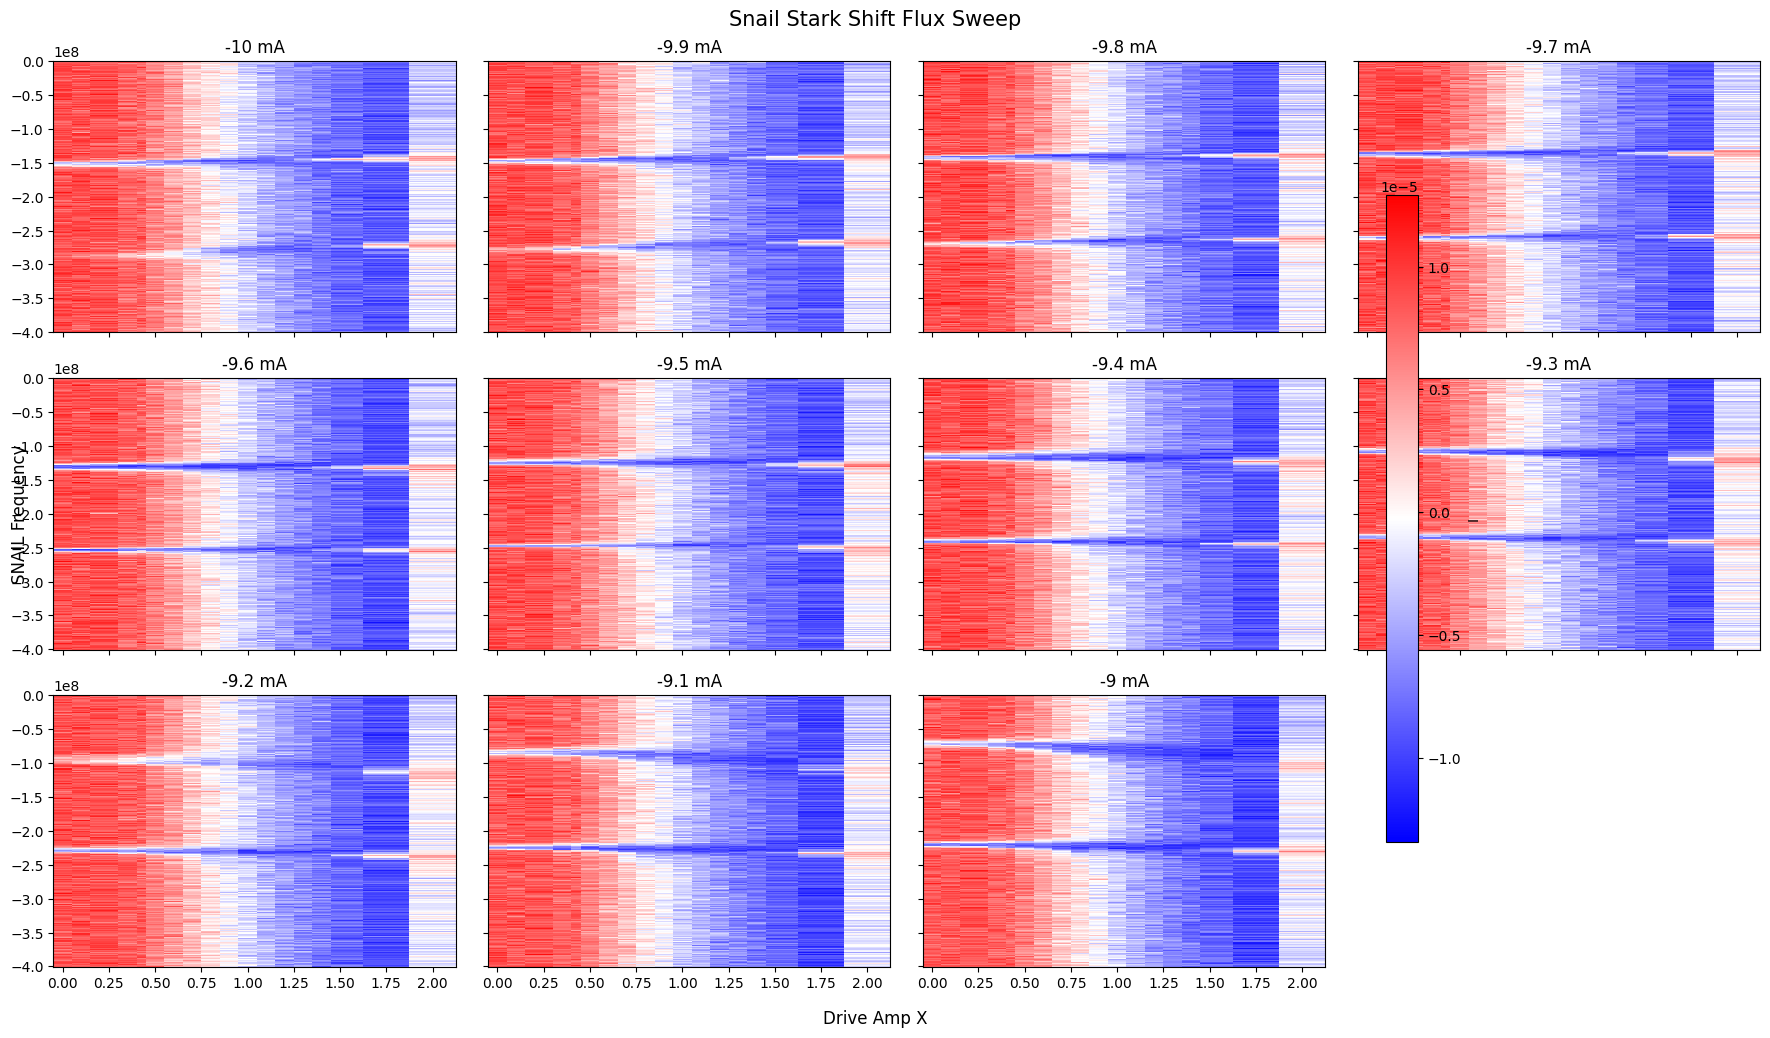

In [ ]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21",
        "start": "10-34-00",
        "stop": "11-17-00",
        "flux": np.linspace(start=-10e-3, stop=-9e-3, num=11),  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "start": "20-09-00",
    #     "stop":  "23-59-00",
    #     "flux": [0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    #     "flux": [600e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

# Save processed state arrays
np.savez(
    "ECD_flux_sweep_sorted.npz",
    flux=flux_sweep_sorted,
    filenames=np.array(filename_list),
    states=np.array(state_list, dtype=object),
    x=np.array(x_list, dtype=object),
    y=np.array(y_list, dtype=object),
)
print("\nSaved ECD_flux_sweep_sorted.npz")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs"
    else:
        label = f"{flux:g} ns"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21
Found 11 files

Saved stark_shift.npz


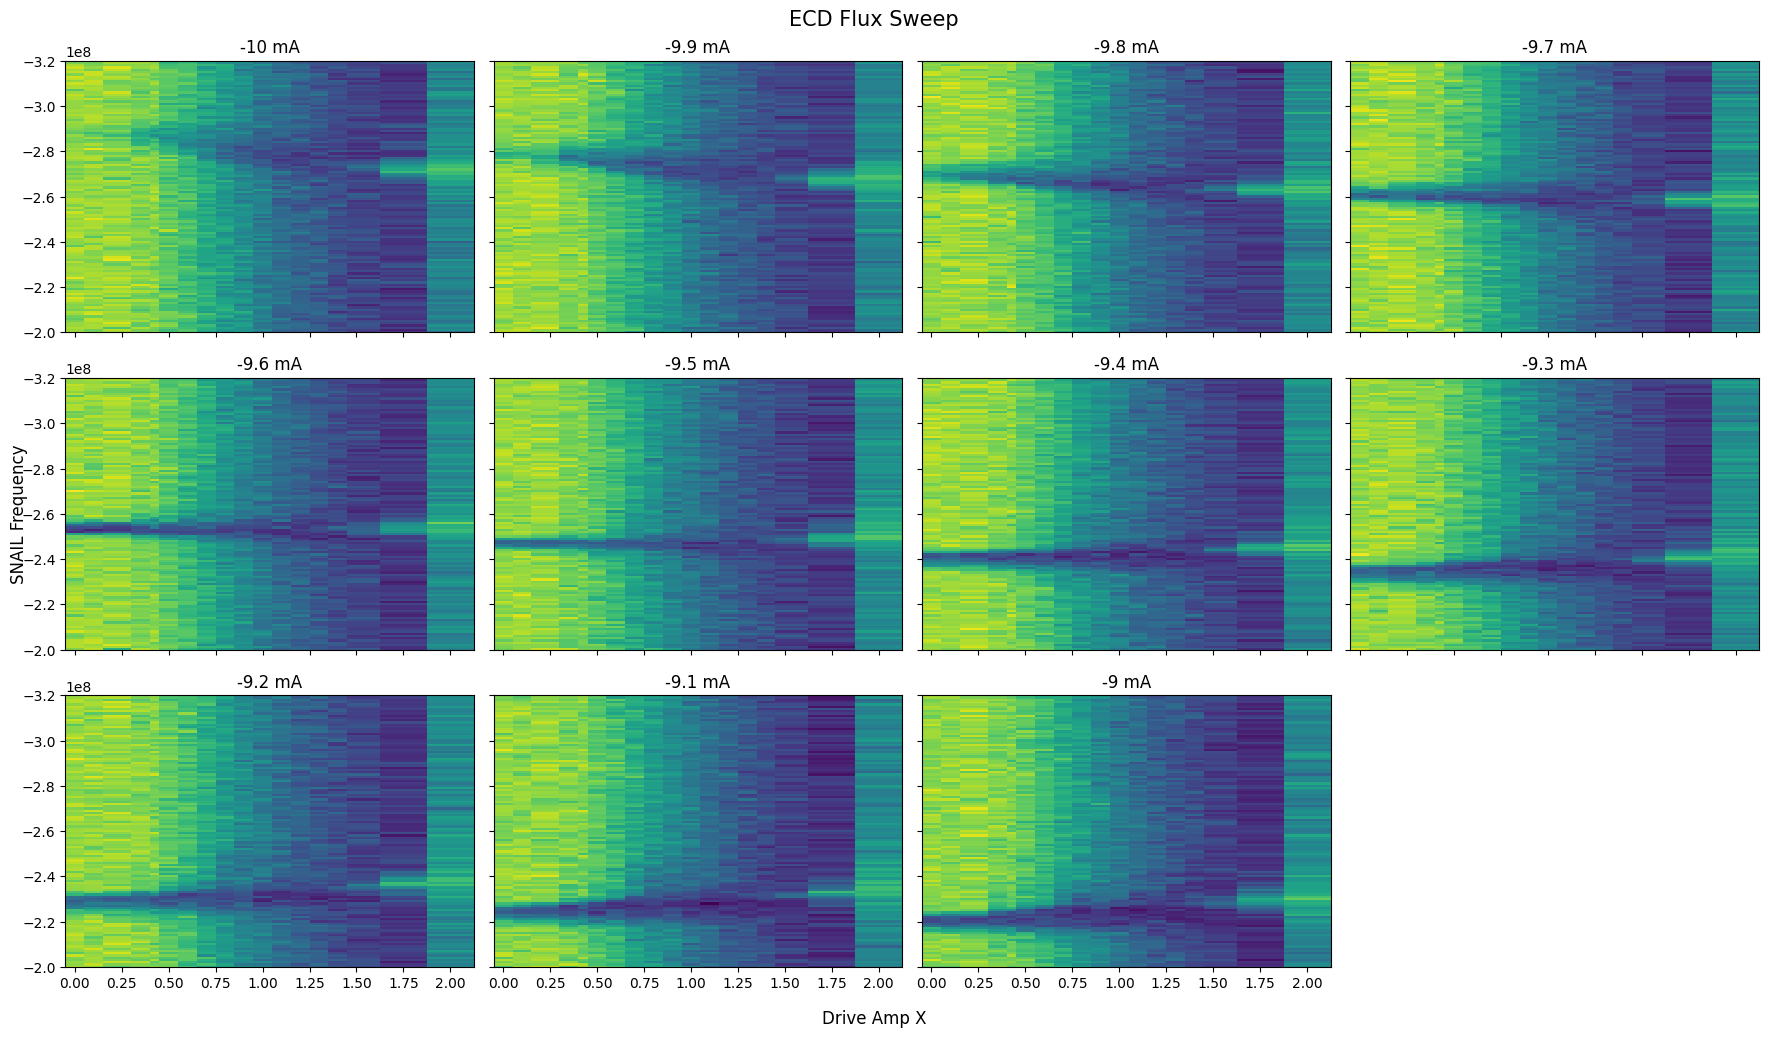

In [44]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21",
        "start": "10-34-00",
        "stop": "11-17-00",
        "flux": np.linspace(start=-10e-3, stop=-9e-3, num=11),  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

# Save processed state arrays
np.savez(
    "stark_shift.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    states=np.array(state_list), # Creates a clean 3D float array
    x=np.array(x_list),
    y=np.array(y_list),
)
print("\nSaved stark_shift.npz")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================

# --- AXIS RANGE CONFIGURATION ---
# Set these to numerical values to crop limits, or leave as None for auto-scaling
xmin = None  # e.g., -0.5
xmax = None  # e.g.,  0.5
ymin = -200e6  # e.g., 4.5e9
ymax = -320e6  # e.g., 5.0e9

num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    # Set custom X & Y ranges if specified
    axes_flat[i].set_xlim(left=xmin, right=xmax)
    axes_flat[i].set_ylim(bottom=ymin, top=ymax)

    flux = flux_sweep_sorted[i]

    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs"
    else:
        label = f"{flux:g} ns"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("ECD Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21
Found 41 files

Files in flux order:

11-24-14_snail_stark_shift_sweep.hdf5 -> Flux: -0.015
11-29-26_snail_stark_shift_sweep.hdf5 -> Flux: -0.01475
11-34-40_snail_stark_shift_sweep.hdf5 -> Flux: -0.014499999999999999
11-39-53_snail_stark_shift_sweep.hdf5 -> Flux: -0.014249999999999999
11-45-06_snail_stark_shift_sweep.hdf5 -> Flux: -0.014
11-50-18_snail_stark_shift_sweep.hdf5 -> Flux: -0.01375
11-55-31_snail_stark_shift_sweep.hdf5 -> Flux: -0.0135
12-00-44_snail_stark_shift_sweep.hdf5 -> Flux: -0.01325
12-05-57_snail_stark_shift_sweep.hdf5 -> Flux: -0.013
12-11-09_snail_stark_shift_sweep.hdf5 -> Flux: -0.012750000000000001
12-16-21_snail_stark_shift_sweep.hdf5 -> Flux: -0.0125
12-21-35_snail_stark_shift_sweep.hdf5 -> Flux: -0.01225
12-26-47_snail_stark_shift_sweep.hdf5 -> Flux: -0.012
12-31-59_snail_stark_shift_sweep.hdf5 -> Flux: -0.01175
12-37-12_snail_stark_shift_sweep.hdf5 -> Flux: -0.0115
12-42-25_snail_stark_shift_sw

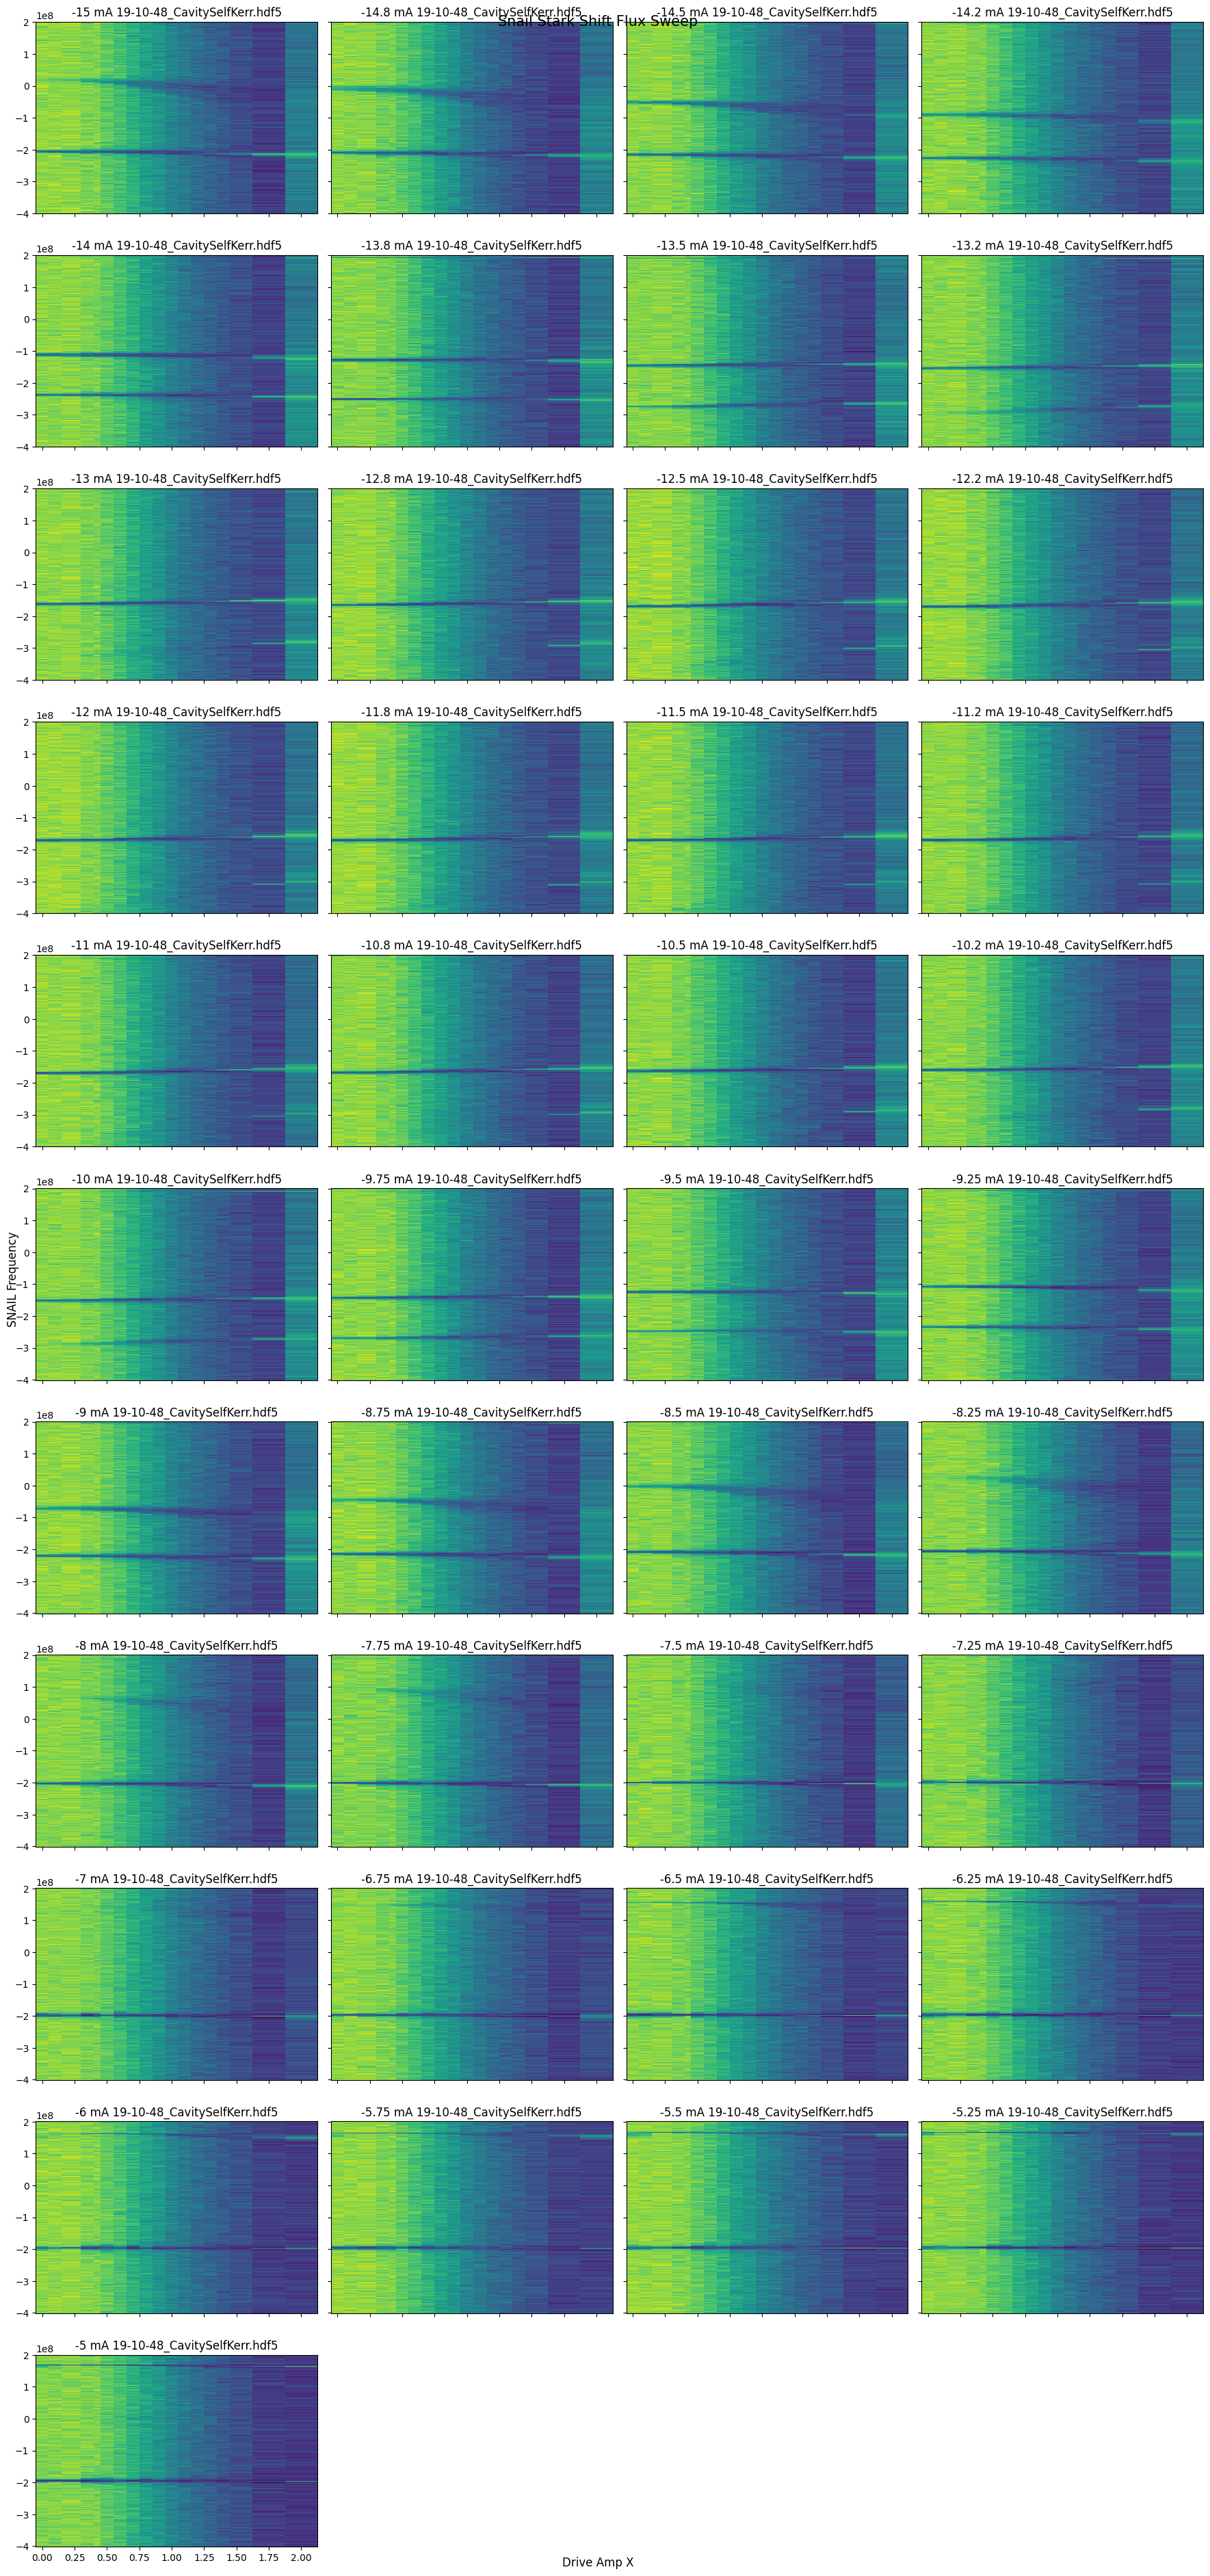

In [49]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21",
        "start": "11-24-00",
        "stop": "14-53-00",
        "flux": np.linspace(start=-15e-3, stop=-5e-3, num=41),  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "start": "20-09-00",
    #     "stop":  "23-59-00",
    #     "flux": [0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    #     "flux": [600e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA {filename}"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs {filename}"
    else:
        label = f"{flux:g} ns{filename}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21
Found 15 files

Files in flux order:

16-30-21_snail_stark_shift_sweep.hdf5 -> Flux: -0.012 | IF: 120.0 MHz
16-35-32_snail_stark_shift_sweep.hdf5 -> Flux: -0.012 | IF: 124.0 MHz
16-40-45_snail_stark_shift_sweep.hdf5 -> Flux: -0.012 | IF: 180.0 MHz
16-15-17_snail_stark_shift_sweep.hdf5 -> Flux: -0.011 | IF: 120.0 MHz
16-20-29_snail_stark_shift_sweep.hdf5 -> Flux: -0.011 | IF: 124.0 MHz
16-25-42_snail_stark_shift_sweep.hdf5 -> Flux: -0.011 | IF: 180.0 MHz
15-59-39_snail_stark_shift_sweep.hdf5 -> Flux: -0.01 | IF: 120.0 MHz
16-04-51_snail_stark_shift_sweep.hdf5 -> Flux: -0.01 | IF: 124.0 MHz
16-10-03_snail_stark_shift_sweep.hdf5 -> Flux: -0.01 | IF: 180.0 MHz
15-44-00_snail_stark_shift_sweep.hdf5 -> Flux: -0.009000000000000001 | IF: 120.0 MHz
15-49-12_snail_stark_shift_sweep.hdf5 -> Flux: -0.009000000000000001 | IF: 124.0 MHz
15-54-24_snail_stark_shift_sweep.hdf5 -> Flux: -0.009000000000000001 | IF: 180.0 MHz
15-28-21_snail_

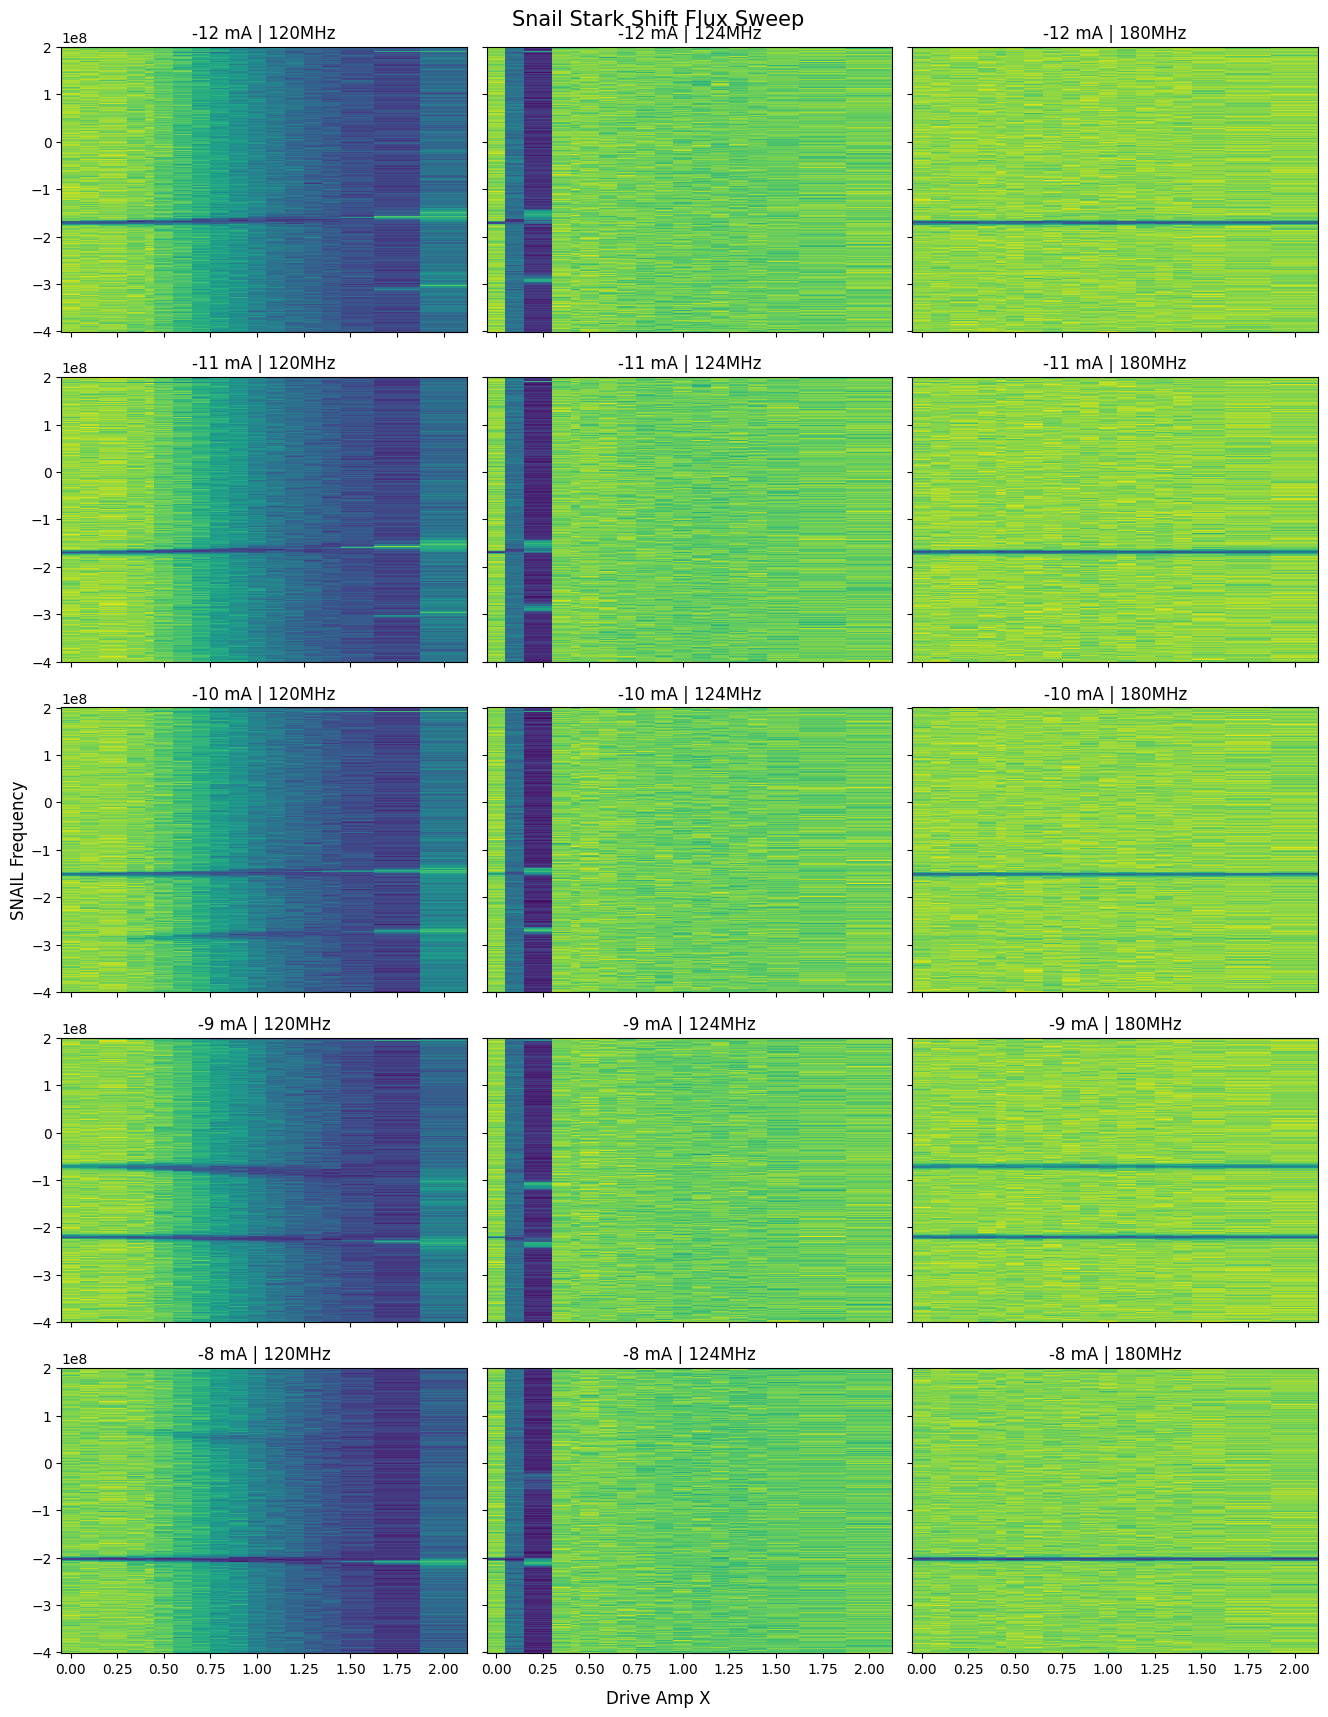

In [41]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np
from itertools import product

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21",
        "start": "15-28-00",
        "stop": "16-41-00",
        "flux": np.linspace(start=-8e-3, stop=-12e-3, num=5),  # mA
        "drive_IF": [120e6, 124e6, 180e6],  # 3 IF values per flux point
    },
]

# ==========================================================
# 2. Collect files and assign (flux, drive_IF) pairs
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    expected_pairs = list(product(cfg["flux"], cfg["drive_IF"]))

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(expected_pairs):
        raise ValueError(
            f"Expected {len(expected_pairs)} files, but found {len(files)}."
        )

    for (flux, drive_if), file in zip(expected_pairs, files):
        paired_data.append((flux, drive_if, file))

# Sort by flux first, then drive_IF for plotting
paired_data.sort(key=lambda x: (x[0], x[1]))

flux_sweep_sorted = [x[0] for x in paired_data]
if_sweep_sorted = [x[1] for x in paired_data]
collected_files_sorted = [x[2] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, drive_if, file in zip(flux_sweep_sorted, if_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux} | IF: {drive_if/1e6:.1f} MHz")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        raw_I = np.array(data["I"])
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

        # Average over extra dimensions if ndim > 2
        while raw_I.ndim > 2:
            raw_I = np.mean(raw_I, axis=0)

        # Ensure state matches (len(y), len(x)) shape for pcolormesh
        if raw_I.shape == (len(x), len(y)):
            state = raw_I.T
        elif raw_I.shape == (len(y), len(x)):
            state = raw_I
        else:
            state = raw_I.T if raw_I.shape[1] == len(y) else raw_I

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

# Safe helper for saving object arrays without broadcasting errors
def to_object_array(data_list):
    arr = np.empty(len(data_list), dtype=object)
    for idx, item in enumerate(data_list):
        arr[idx] = item
    return arr

# Save processed state arrays
np.savez(
    "ECD_flux_sweep_sorted.npz",
    flux=flux_sweep_sorted,
    drive_IF=if_sweep_sorted,
    filenames=np.array(filename_list),
    states=to_object_array(state_list),
    x=to_object_array(x_list),
    y=to_object_array(y_list),
)
print("\nSaved ECD_flux_sweep_sorted.npz")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 3
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]
    drive_if = if_sweep_sorted[i]
    filename = filename_list[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA | {drive_if/1e6:.0f}MHz"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs | {drive_if/1e6:.0f}MHz"
    else:
        label = f"{flux:g} ns | {drive_if/1e6:.0f}MHz"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()

In [47]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21",
        "start": "17-47-00",
        "stop": "18-53-00",
        "flux": np.linspace(start=-15e-3, stop=-5e-3, num=5),  # mA
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

# Save processed state arrays
np.savez(
    "ECD_flux_sweep_sorted.npz",
    flux=flux_sweep_sorted,
    filenames=np.array(filename_list),
    states=np.array(state_list, dtype=object),
    x=np.array(x_list, dtype=object),
    y=np.array(y_list, dtype=object),
)
print("\nSaved ECD_flux_sweep_sorted.npz")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA {filename}"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs {filename}"
    else:
        label = f"{flux:g} ns{filename}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21
Found 1 files


ValueError: Expected 5 files, but found 1.


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 3 files

Files in flux order:

11-29-51_snail_stark_shift_sweep.hdf5 -> Flux: -0.012
11-26-53_snail_stark_shift_sweep.hdf5 -> Flux: -0.009
11-23-53_snail_stark_shift_sweep.hdf5 -> Flux: -0.005

Saved stark_shift.npz successfully.


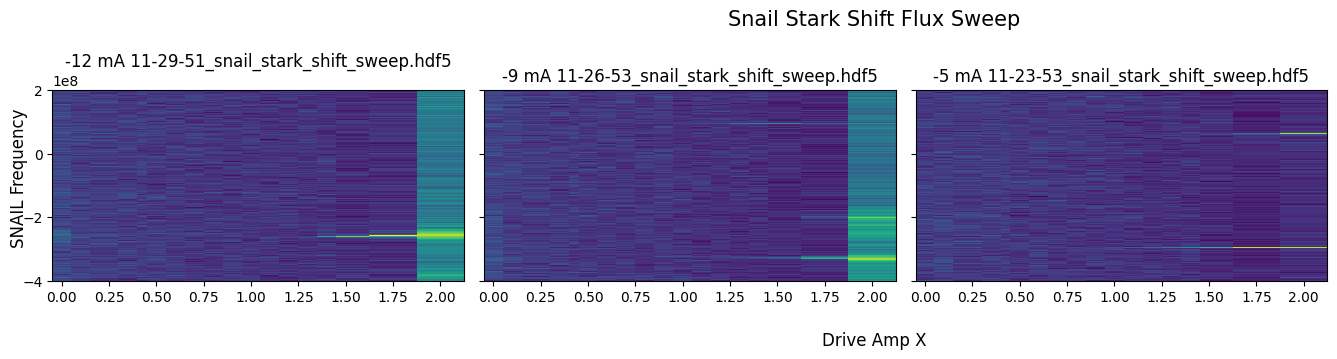

In [52]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "11-23-00",
        "stop": "11-35-00",
        "flux": [-5e-3, -9e-3, -12e-3],  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "start": "20-09-00",
    #     "stop":  "23-59-00",
    #     "flux": [0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    #     "flux": [600e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA {filename_list[i]}"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs {filename_list[i]}"
    else:
        label = f"{flux:g} ns{filename_list[i]}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 3 files

Files in flux order:

11-49-14_snail_stark_shift_sweep.hdf5 -> Flux: -0.012
11-43-55_snail_stark_shift_sweep.hdf5 -> Flux: -0.009
11-38-33_snail_stark_shift_sweep.hdf5 -> Flux: -0.005

Saved stark_shift.npz successfully.


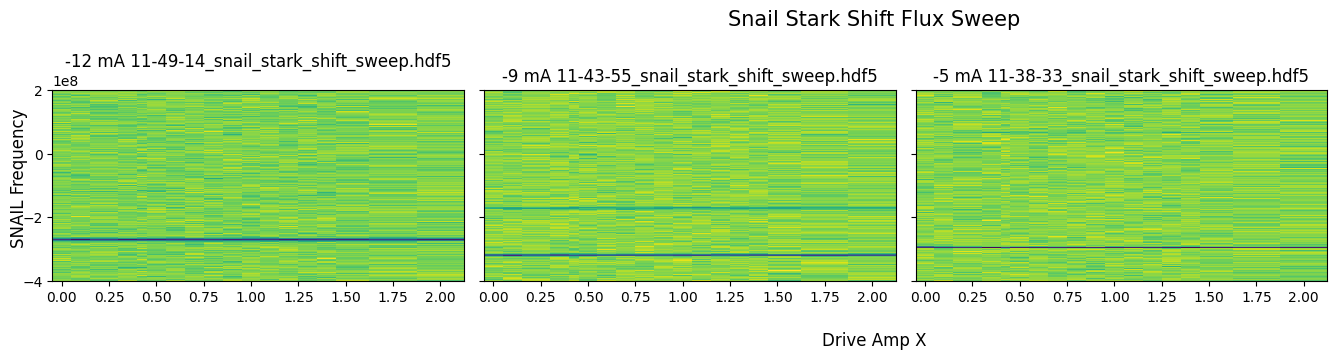

In [56]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "11-38-00",
        "stop": "11-50-00",
        "flux": [-5e-3, -9e-3, -12e-3],  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "start": "20-09-00",
    #     "stop":  "23-59-00",
    #     "flux": [0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    #     "flux": [600e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA {filename_list[i]}"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs {filename_list[i]}"
    else:
        label = f"{flux:g} ns{filename_list[i]}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 3 files

Files in flux order:

13-33-37_snail_stark_shift_sweep.hdf5 -> Flux: -0.012
13-28-18_snail_stark_shift_sweep.hdf5 -> Flux: -0.009
13-22-57_snail_stark_shift_sweep.hdf5 -> Flux: -0.005

Saved stark_shift.npz successfully.


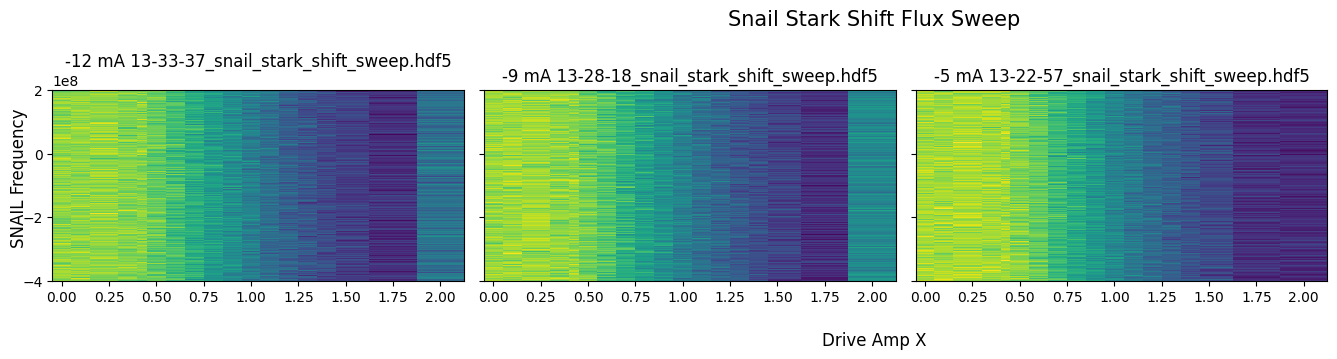

In [59]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "13-21-00",
        "stop": "13-39-00",
        "flux": [-5e-3, -9e-3, -12e-3],  # mA
    },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "10-41-00",
    #     "stop":  "12-10-53",
    #     "flux": [1e3, 2.5e3, 5e3, 8e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "start": "20-09-00",
    #     "stop":  "23-59-00",
    #     "flux": [0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
    # },
    # {
    #     "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
    #     "start": "00-00-00",
    #     "stop":  "07-52-00",
    #     "flux": [600e3],
    # },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Flux: {flux}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    flux = flux_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(flux) < 1.0:
        label = f"{flux*1e3:.3g} mA {filename_list[i]}"
    elif flux >= 1000:
        label = f"{flux/1000:g} μs {filename_list[i]}"
    else:
        label = f"{flux:g} ns{filename_list[i]}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift Flux Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 4 files

Files in drive_len order:

13-49-21_snail_stark_shift.hdf5 -> drive_len: 100
13-55-49_snail_stark_shift.hdf5 -> drive_len: 500
14-00-52_snail_stark_shift.hdf5 -> drive_len: 1000
14-07-52_snail_stark_shift.hdf5 -> drive_len: 5000

Saved stark_shift.npz successfully.


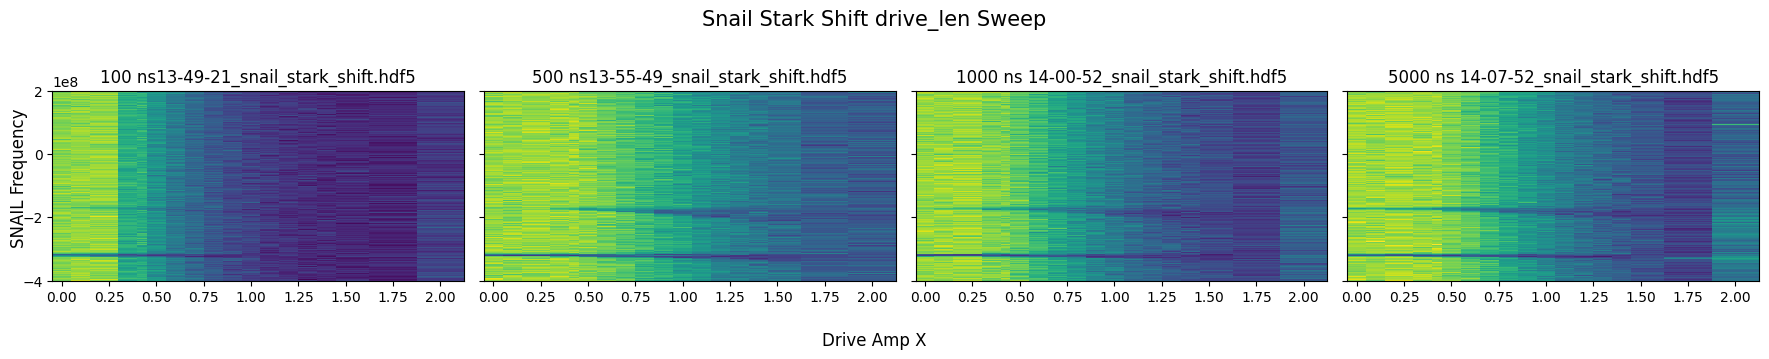

In [63]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "13-48-00",
        "stop": "14-08-00",
        "drive_len": [100, 500, 1000, 5000],  # mA
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["drive_len"]):
        raise ValueError(
            f"Expected {len(cfg['drive_len'])} files, but found {len(files)}."
        )

    for drive_len, file in zip(cfg["drive_len"], files):
        paired_data.append((drive_len, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

drive_len_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in drive_len order:\n")
for drive_len, file in zip(drive_len_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> drive_len: {drive_len}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for drive_len, file_path in zip(drive_len_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    drive_len=drive_len_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    drive_len = drive_len_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(drive_len) < 1.0:
        label = f"{drive_len:g} ns {filename_list[i]}"
    elif drive_len >= 1000:
        label = f"{drive_len:g} ns {filename_list[i]}"
    else:
        label = f"{drive_len:g} ns{filename_list[i]}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift drive_len Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 2 files

Files in drive_len order:

14-21-21_snail_stark_shift.hdf5 -> drive_len: 100
14-28-59_snail_stark_shift.hdf5 -> drive_len: 500

Saved stark_shift.npz successfully.


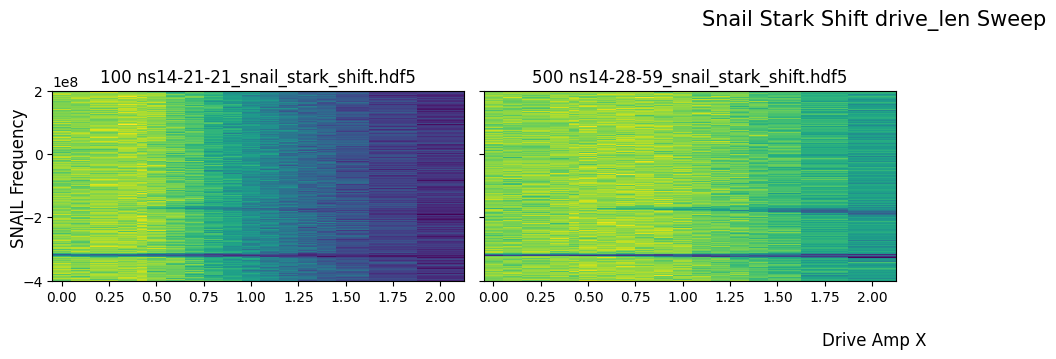

In [64]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "14-20-00",
        "stop": "14-38-00",
        "drive_len": [100, 500],  # mA
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "snail_stark_shift" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["drive_len"]):
        raise ValueError(
            f"Expected {len(cfg['drive_len'])} files, but found {len(files)}."
        )

    for drive_len, file in zip(cfg["drive_len"], files):
        paired_data.append((drive_len, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

drive_len_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in drive_len order:\n")
for drive_len, file in zip(drive_len_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> drive_len: {drive_len}")

# ==========================================================
# 3. Load all HDF5 data and extract values
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for drive_len, file_path in zip(drive_len_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["drive_ampx"])
        y = np.array(data["snail_frequency"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

try:
    # Try saving as clean, uniform N-dimensional numeric arrays
    states_arr = np.array(state_list, dtype=np.float64)
    x_arr = np.array(x_list, dtype=np.float64)
    y_arr = np.array(y_list, dtype=np.float64)
except ValueError:
    # Fallback if HDF5 grid dimensions differ across files
    states_arr = np.array(state_list, dtype=object)
    x_arr = np.array(x_list, dtype=object)
    y_arr = np.array(y_list, dtype=object)

np.savez(
    "stark_shift.npz",
    drive_len=drive_len_sweep_sorted,
    filenames=filename_list,
    states=states_arr,
    x=x_arr,
    y=y_arr,
)
print("\nSaved stark_shift.npz successfully.")

# ==========================================================
# 4. Plot grid for all collected files
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    im = axes_flat[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    drive_len = drive_len_sweep_sorted[i]

    # Smart label formatting: mA for current (e.g. -0.010 to -0.009), ns/μs for pulse time
    if abs(drive_len) < 1.0:
        label = f"{drive_len:g} ns {filename_list[i]}"
    elif drive_len >= 1000:
        label = f"{drive_len:g} ns {filename_list[i]}"
    else:
        label = f"{drive_len:g} ns{filename_list[i]}"

    axes_flat[i].set_title(label)

# Clean up unused grid cells
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Global Labels & Layout
fig.supxlabel("Drive Amp X")
fig.supylabel("SNAIL Frequency")
# fig.colorbar(im, ax=axes_flat[:num_plots], shrink=0.8, label="I")

plt.suptitle("Snail Stark Shift drive_len Sweep", fontsize=15)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 71 files

Files in drive_IF order:

15-02-09_RRSpec_drive_sweep.hdf5 -> drive_IF: 70000000.0 MHz
15-02-34_RRSpec_drive_sweep.hdf5 -> drive_IF: 71000000.0 MHz
15-03-00_RRSpec_drive_sweep.hdf5 -> drive_IF: 72000000.0 MHz
15-03-26_RRSpec_drive_sweep.hdf5 -> drive_IF: 73000000.0 MHz
15-03-52_RRSpec_drive_sweep.hdf5 -> drive_IF: 74000000.0 MHz
15-04-17_RRSpec_drive_sweep.hdf5 -> drive_IF: 75000000.0 MHz
15-04-44_RRSpec_drive_sweep.hdf5 -> drive_IF: 76000000.0 MHz
15-05-10_RRSpec_drive_sweep.hdf5 -> drive_IF: 77000000.0 MHz
15-05-35_RRSpec_drive_sweep.hdf5 -> drive_IF: 78000000.0 MHz
15-06-01_RRSpec_drive_sweep.hdf5 -> drive_IF: 79000000.0 MHz
15-06-27_RRSpec_drive_sweep.hdf5 -> drive_IF: 80000000.0 MHz
15-06-52_RRSpec_drive_sweep.hdf5 -> drive_IF: 81000000.0 MHz
15-07-17_RRSpec_drive_sweep.hdf5 -> drive_IF: 82000000.0 MHz
15-07-43_RRSpec_drive_sweep.hdf5 -> drive_IF: 83000000.0 MHz
15-08-08_RRSpec_drive_sweep.hdf5 -> dri

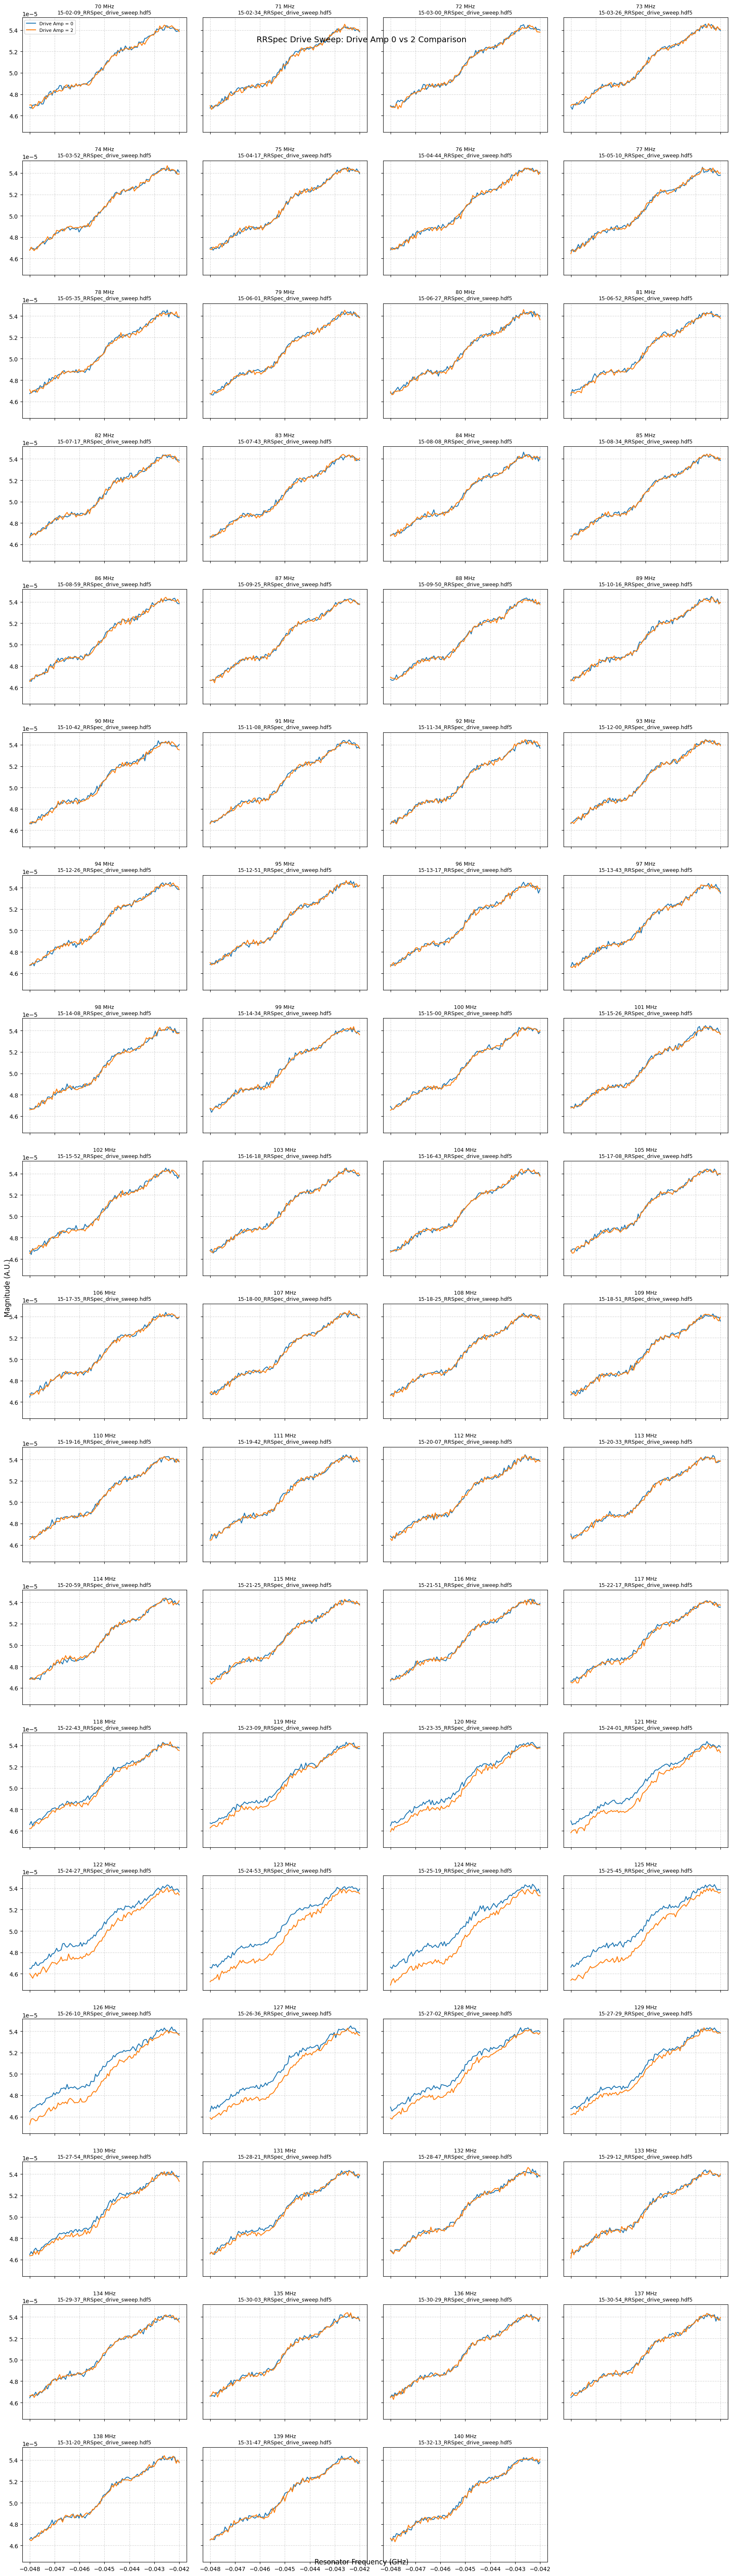

In [83]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
start = 70e6
step = 1e6
num = 71

search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "15-02-00",
        "stop": "15-33-00",
        "drive_IF": np.arange(start, start + num * step, step)
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["drive_IF"]):
        raise ValueError(
            f"Expected {len(cfg['drive_IF'])} files, but found {len(files)}."
        )

    for drive_IF, file in zip(cfg["drive_IF"], files):
        paired_data.append((drive_IF, file))

# Sort by drive_IF for plotting
paired_data.sort(key=lambda x: x[0])

drive_IF_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in drive_IF order:\n")
for drive_IF, file in zip(drive_IF_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> drive_IF: {drive_IF} MHz")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0 and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp2_list = []
filename_list = []

for drive_IF, file_path in zip(drive_IF_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0 and drive_ampx = 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Save processed slices to NPZ
np.savez(
    "stark_shift_magnitude_traces.npz",
    drive_IF=drive_IF_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("\nSaved stark_shift_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot both line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    drive_IF_MHz = drive_IF_sweep_sorted[i] / 1e6 if drive_IF_sweep_sorted[i] >= 1e3 else drive_IF_sweep_sorted[i]
    label = f"{drive_IF_MHz:g} MHz\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("RRSpec Drive Sweep: Drive Amp 0 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 13 files

Files in flux order:

16-11-55_RRSpec_drive_sweep.hdf5 -> flux: -12 mA
16-11-15_RRSpec_drive_sweep.hdf5 -> flux: -11.5 mA
16-10-36_RRSpec_drive_sweep.hdf5 -> flux: -11 mA
16-09-56_RRSpec_drive_sweep.hdf5 -> flux: -10.5 mA
16-09-17_RRSpec_drive_sweep.hdf5 -> flux: -10 mA
16-08-38_RRSpec_drive_sweep.hdf5 -> flux: -9.5 mA
16-07-59_RRSpec_drive_sweep.hdf5 -> flux: -9 mA
16-07-20_RRSpec_drive_sweep.hdf5 -> flux: -8.5 mA
16-06-40_RRSpec_drive_sweep.hdf5 -> flux: -8 mA
16-06-01_RRSpec_drive_sweep.hdf5 -> flux: -7.5 mA
16-05-21_RRSpec_drive_sweep.hdf5 -> flux: -7 mA
16-04-42_RRSpec_drive_sweep.hdf5 -> flux: -6.5 mA
16-04-03_RRSpec_drive_sweep.hdf5 -> flux: -6 mA

Saved stark_shift_magnitude_traces.npz successfully.


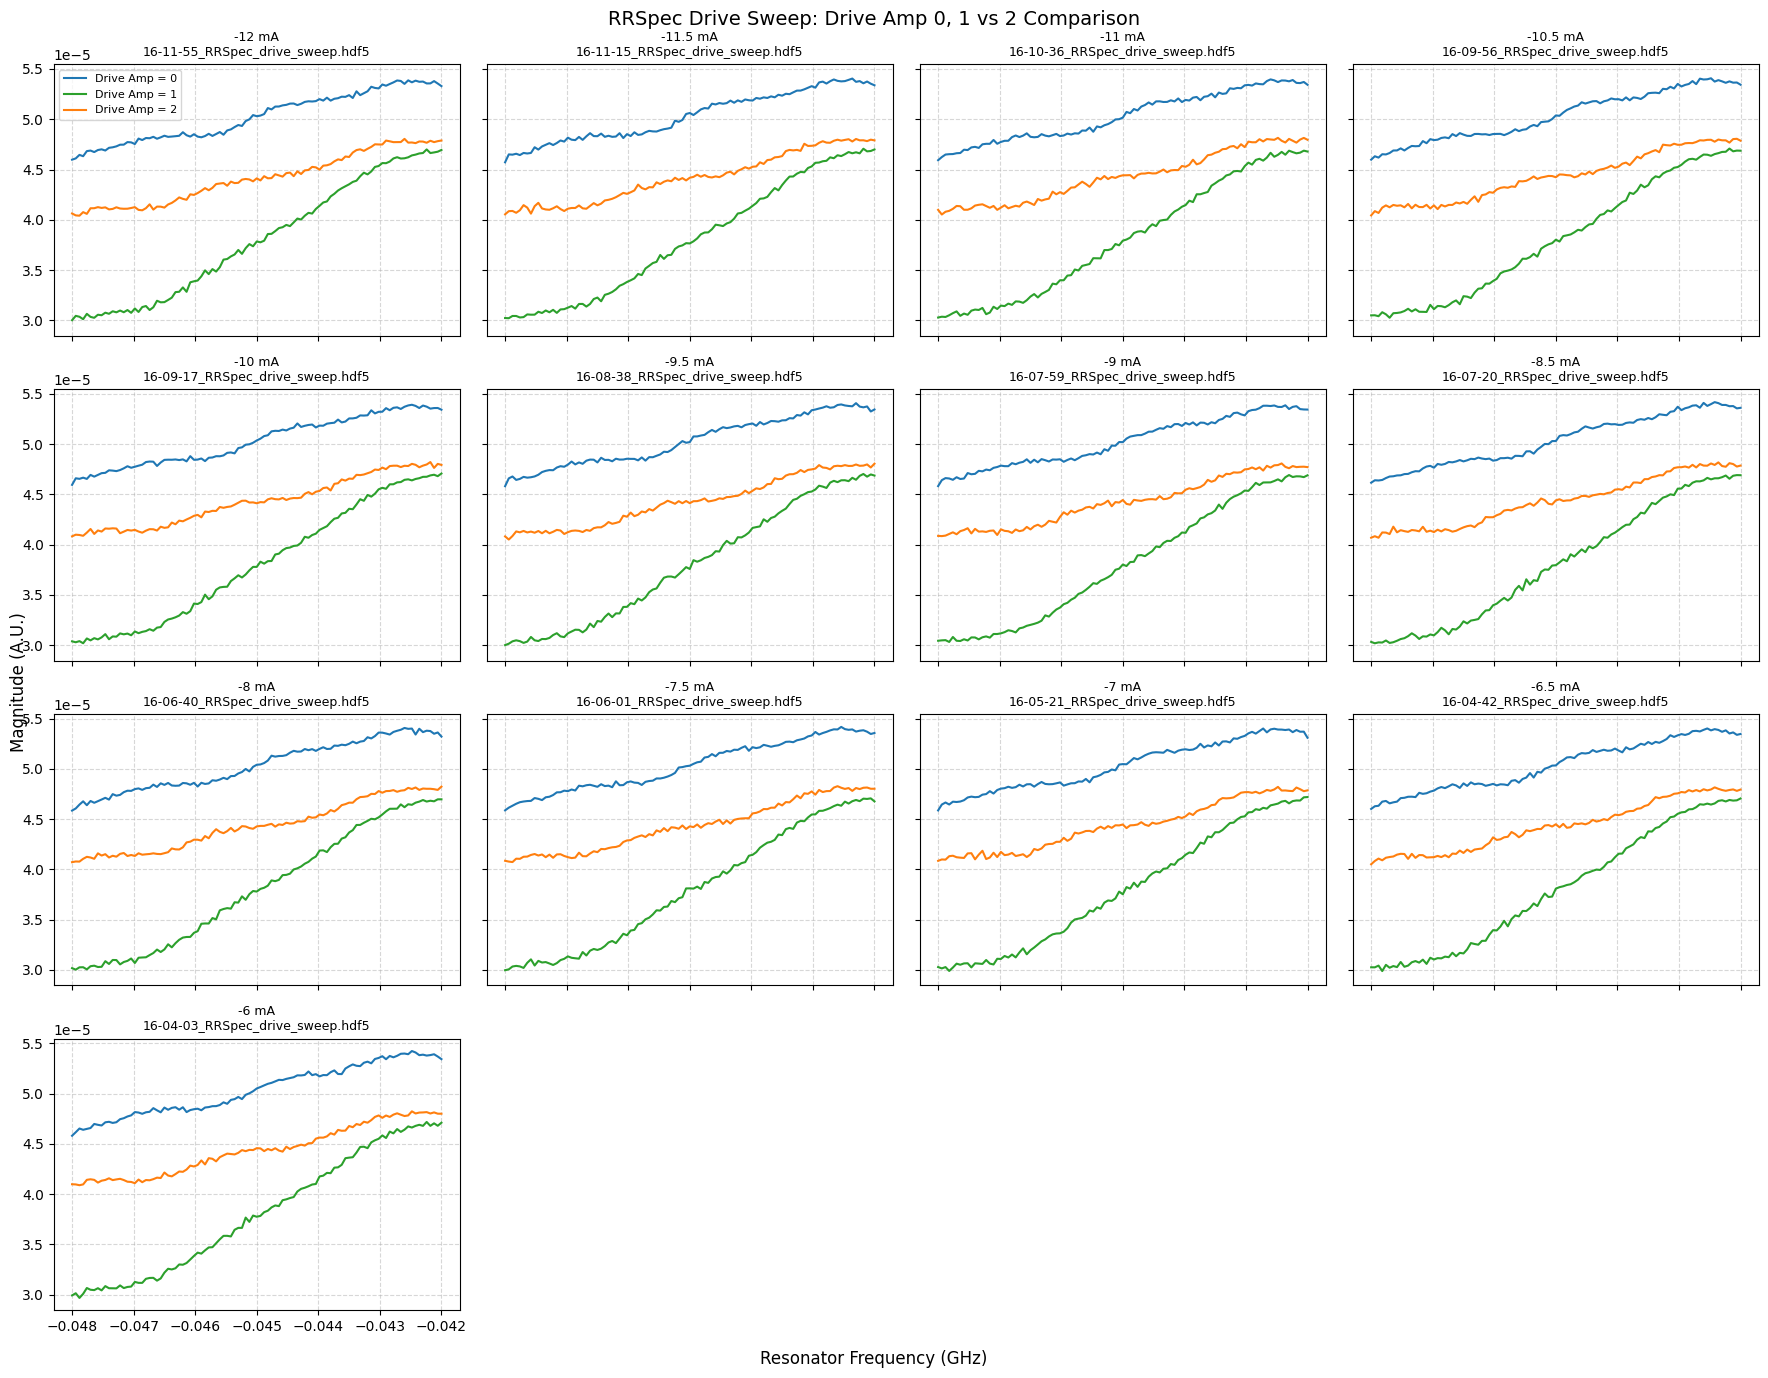

In [85]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "16-04-00",
        "stop": "16-20-00",
        "flux": np.linspace(start=-6e-3, stop=-12e-3, num=13),
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> flux: {flux*1e3:.3g} mA")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0, 1, and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp1_list = []
mag_amp2_list = []
filename_list = []

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0, 1, and 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp1 = np.argmin(np.abs(drive_amp - 1.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp1 = mag[idx_amp1, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp1 = mag[:, idx_amp1]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp1_list.append(mag_amp1)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Save processed slices to NPZ
np.savez(
    "stark_shift_magnitude_traces.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp1=np.array(mag_amp1_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("\nSaved stark_shift_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0, 1 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot all three line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp1_list[i], label="Drive Amp = 1", color="tab:green", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    flux = flux_sweep_sorted[i]
    label = f"{flux*1e3:.3g} mA\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("RRSpec Drive Sweep: Drive Amp 0, 1 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 13 files

Files in flux order:

16-59-44_RRSpec_drive_sweep.hdf5 -> flux: -12 mA
16-59-06_RRSpec_drive_sweep.hdf5 -> flux: -11.5 mA
16-58-28_RRSpec_drive_sweep.hdf5 -> flux: -11 mA
16-57-50_RRSpec_drive_sweep.hdf5 -> flux: -10.5 mA
16-57-12_RRSpec_drive_sweep.hdf5 -> flux: -10 mA
16-56-33_RRSpec_drive_sweep.hdf5 -> flux: -9.5 mA
16-55-55_RRSpec_drive_sweep.hdf5 -> flux: -9 mA
16-55-17_RRSpec_drive_sweep.hdf5 -> flux: -8.5 mA
16-54-39_RRSpec_drive_sweep.hdf5 -> flux: -8 mA
16-54-01_RRSpec_drive_sweep.hdf5 -> flux: -7.5 mA
16-53-23_RRSpec_drive_sweep.hdf5 -> flux: -7 mA
16-52-44_RRSpec_drive_sweep.hdf5 -> flux: -6.5 mA
16-52-05_RRSpec_drive_sweep.hdf5 -> flux: -6 mA

Saved stark_shift_magnitude_traces.npz successfully.


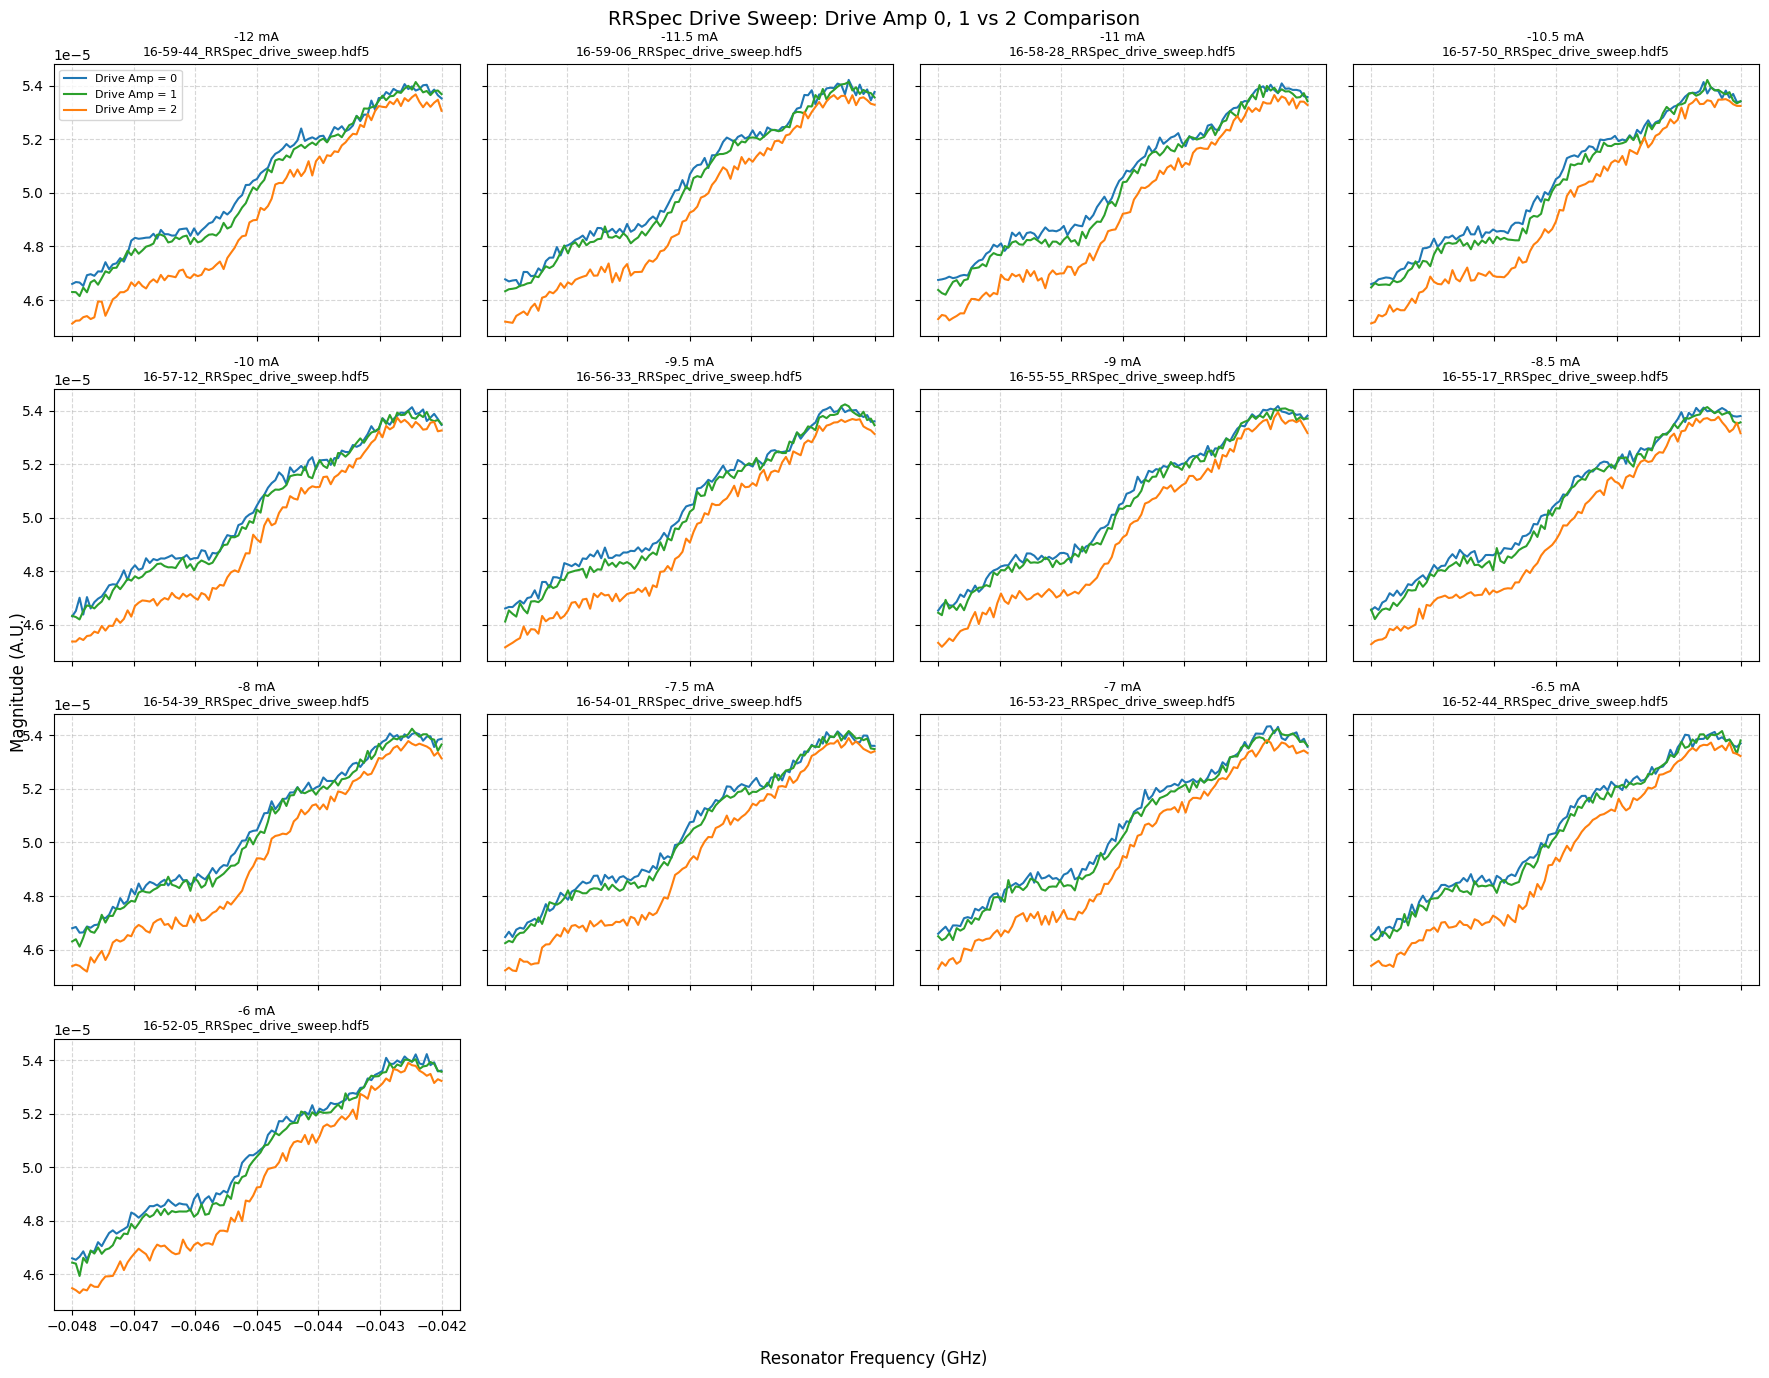

In [86]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "16-52-00",
        "stop": "17-00-00",
        "flux": np.linspace(start=-6e-3, stop=-12e-3, num=13),
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> flux: {flux*1e3:.3g} mA")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0, 1, and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp1_list = []
mag_amp2_list = []
filename_list = []

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0, 1, and 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp1 = np.argmin(np.abs(drive_amp - 1.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp1 = mag[idx_amp1, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp1 = mag[:, idx_amp1]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp1_list.append(mag_amp1)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Save processed slices to NPZ
np.savez(
    "stark_shift_magnitude_traces.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp1=np.array(mag_amp1_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("\nSaved stark_shift_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0, 1 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot all three line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp1_list[i], label="Drive Amp = 1", color="tab:green", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    flux = flux_sweep_sorted[i]
    label = f"{flux*1e3:.3g} mA\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("RRSpec Drive Sweep: Drive Amp 0, 1 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22
Found 11 files

Files in flux order:

17-10-18_RRSpec_drive_sweep.hdf5 -> flux: -11 mA
17-09-39_RRSpec_drive_sweep.hdf5 -> flux: -10.5 mA
17-09-00_RRSpec_drive_sweep.hdf5 -> flux: -10 mA
17-08-18_RRSpec_drive_sweep.hdf5 -> flux: -9.5 mA
17-07-39_RRSpec_drive_sweep.hdf5 -> flux: -9 mA
17-07-01_RRSpec_drive_sweep.hdf5 -> flux: -8.5 mA
17-06-22_RRSpec_drive_sweep.hdf5 -> flux: -8 mA
17-05-44_RRSpec_drive_sweep.hdf5 -> flux: -7.5 mA
17-05-06_RRSpec_drive_sweep.hdf5 -> flux: -7 mA
17-04-27_RRSpec_drive_sweep.hdf5 -> flux: -6.5 mA
17-03-48_RRSpec_drive_sweep.hdf5 -> flux: -6 mA

Saved stark_shift_magnitude_traces.npz successfully.


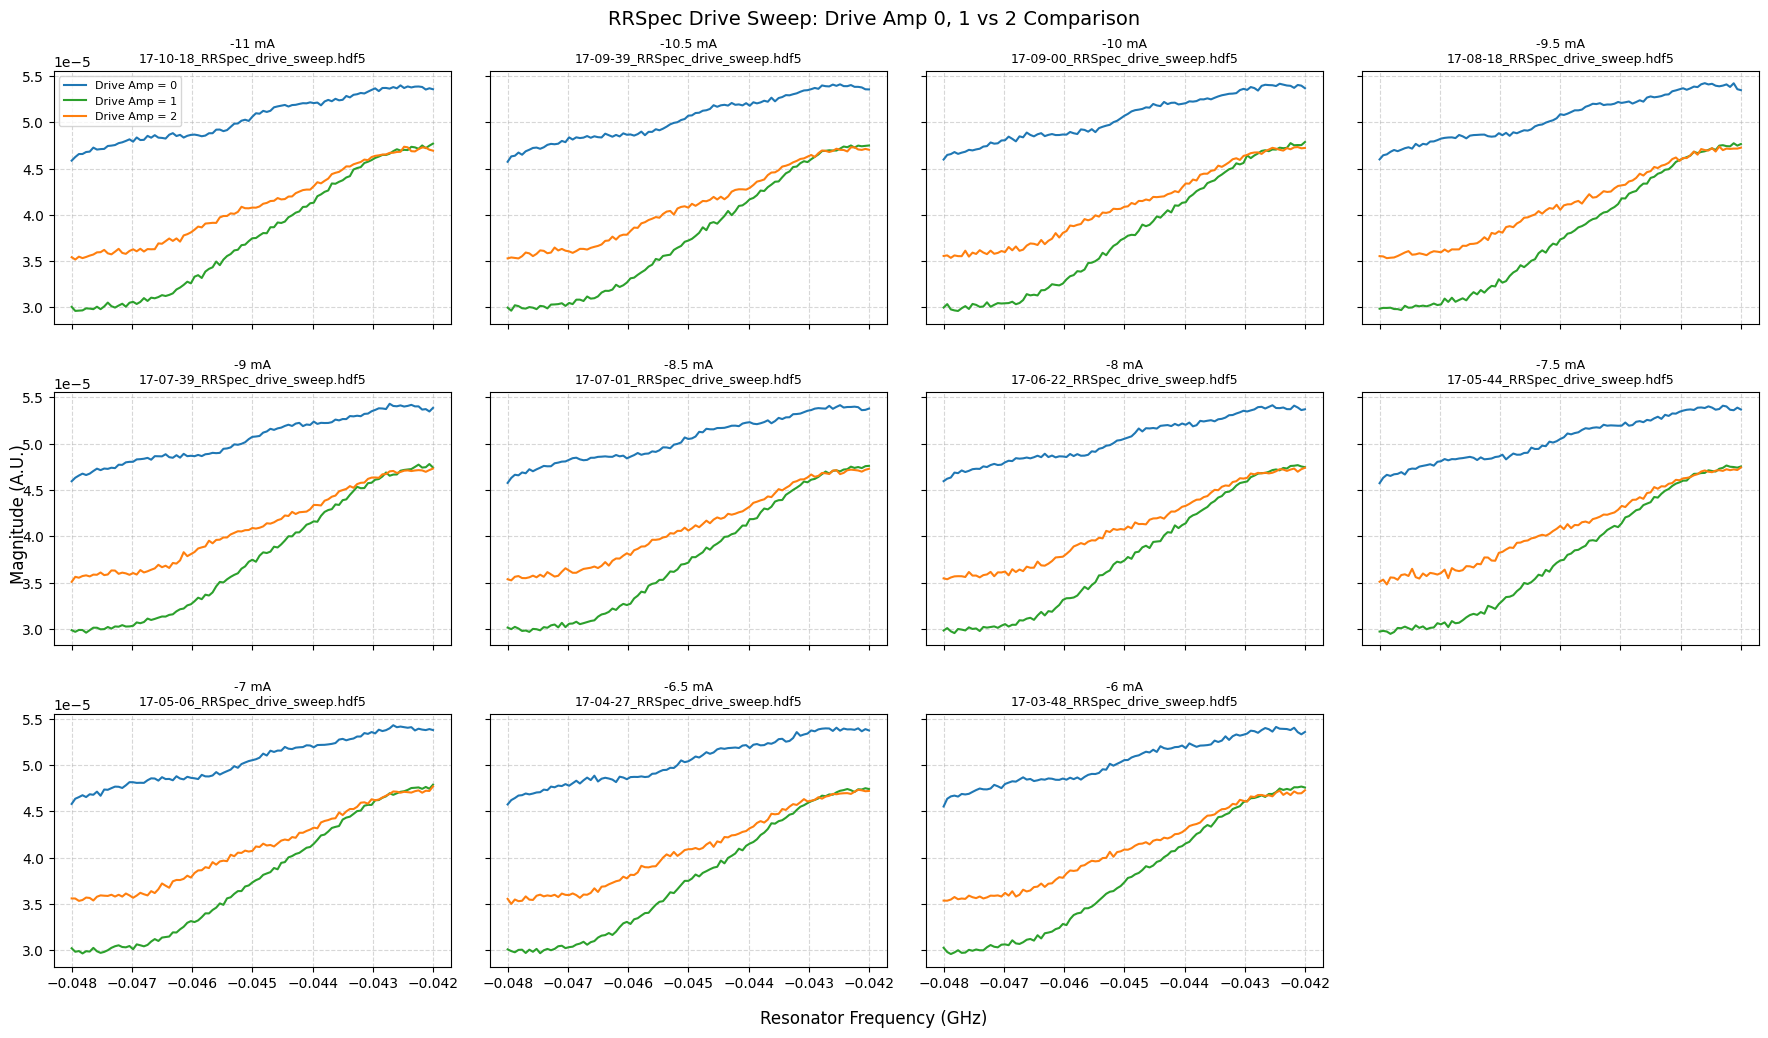

In [89]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-22",
        "start": "17-03-00",
        "stop": "17-10-30",
        "flux": np.linspace(start=-6e-3, stop=-11e-3, num=11),
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["flux"]):
        raise ValueError(
            f"Expected {len(cfg['flux'])} files, but found {len(files)}."
        )

    for flux, file in zip(cfg["flux"], files):
        paired_data.append((flux, file))

# Sort by flux for plotting
paired_data.sort(key=lambda x: x[0])

flux_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in flux order:\n")
for flux, file in zip(flux_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> flux: {flux*1e3:.3g} mA")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0, 1, and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp1_list = []
mag_amp2_list = []
filename_list = []

for flux, file_path in zip(flux_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0, 1, and 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp1 = np.argmin(np.abs(drive_amp - 1.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp1 = mag[idx_amp1, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp1 = mag[:, idx_amp1]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp1_list.append(mag_amp1)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Save processed slices to NPZ
np.savez(
    "stark_shift_magnitude_traces.npz",
    flux=flux_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp1=np.array(mag_amp1_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("\nSaved stark_shift_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0, 1 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot all three line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp1_list[i], label="Drive Amp = 1", color="tab:green", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    flux = flux_sweep_sorted[i]
    label = f"{flux*1e3:.3g} mA\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("RRSpec Drive Sweep: Drive Amp 0, 1 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-23
Found 51 files

Files in drive_IF order:

09-48-35_RRSpec_drive_sweep.hdf5 -> drive_IF: -50 MHz
09-49-02_RRSpec_drive_sweep.hdf5 -> drive_IF: -48 MHz
09-49-28_RRSpec_drive_sweep.hdf5 -> drive_IF: -46 MHz
09-49-56_RRSpec_drive_sweep.hdf5 -> drive_IF: -44 MHz
09-50-23_RRSpec_drive_sweep.hdf5 -> drive_IF: -42 MHz
09-50-49_RRSpec_drive_sweep.hdf5 -> drive_IF: -40 MHz
09-51-16_RRSpec_drive_sweep.hdf5 -> drive_IF: -38 MHz
09-51-43_RRSpec_drive_sweep.hdf5 -> drive_IF: -36 MHz
09-52-10_RRSpec_drive_sweep.hdf5 -> drive_IF: -34 MHz
09-52-37_RRSpec_drive_sweep.hdf5 -> drive_IF: -32 MHz
09-53-04_RRSpec_drive_sweep.hdf5 -> drive_IF: -30 MHz
09-53-32_RRSpec_drive_sweep.hdf5 -> drive_IF: -28 MHz
09-53-58_RRSpec_drive_sweep.hdf5 -> drive_IF: -26 MHz
09-54-26_RRSpec_drive_sweep.hdf5 -> drive_IF: -24 MHz
09-54-53_RRSpec_drive_sweep.hdf5 -> drive_IF: -22 MHz
09-55-20_RRSpec_drive_sweep.hdf5 -> drive_IF: -20 MHz
09-55-46_RRSpec_drive_sweep.h

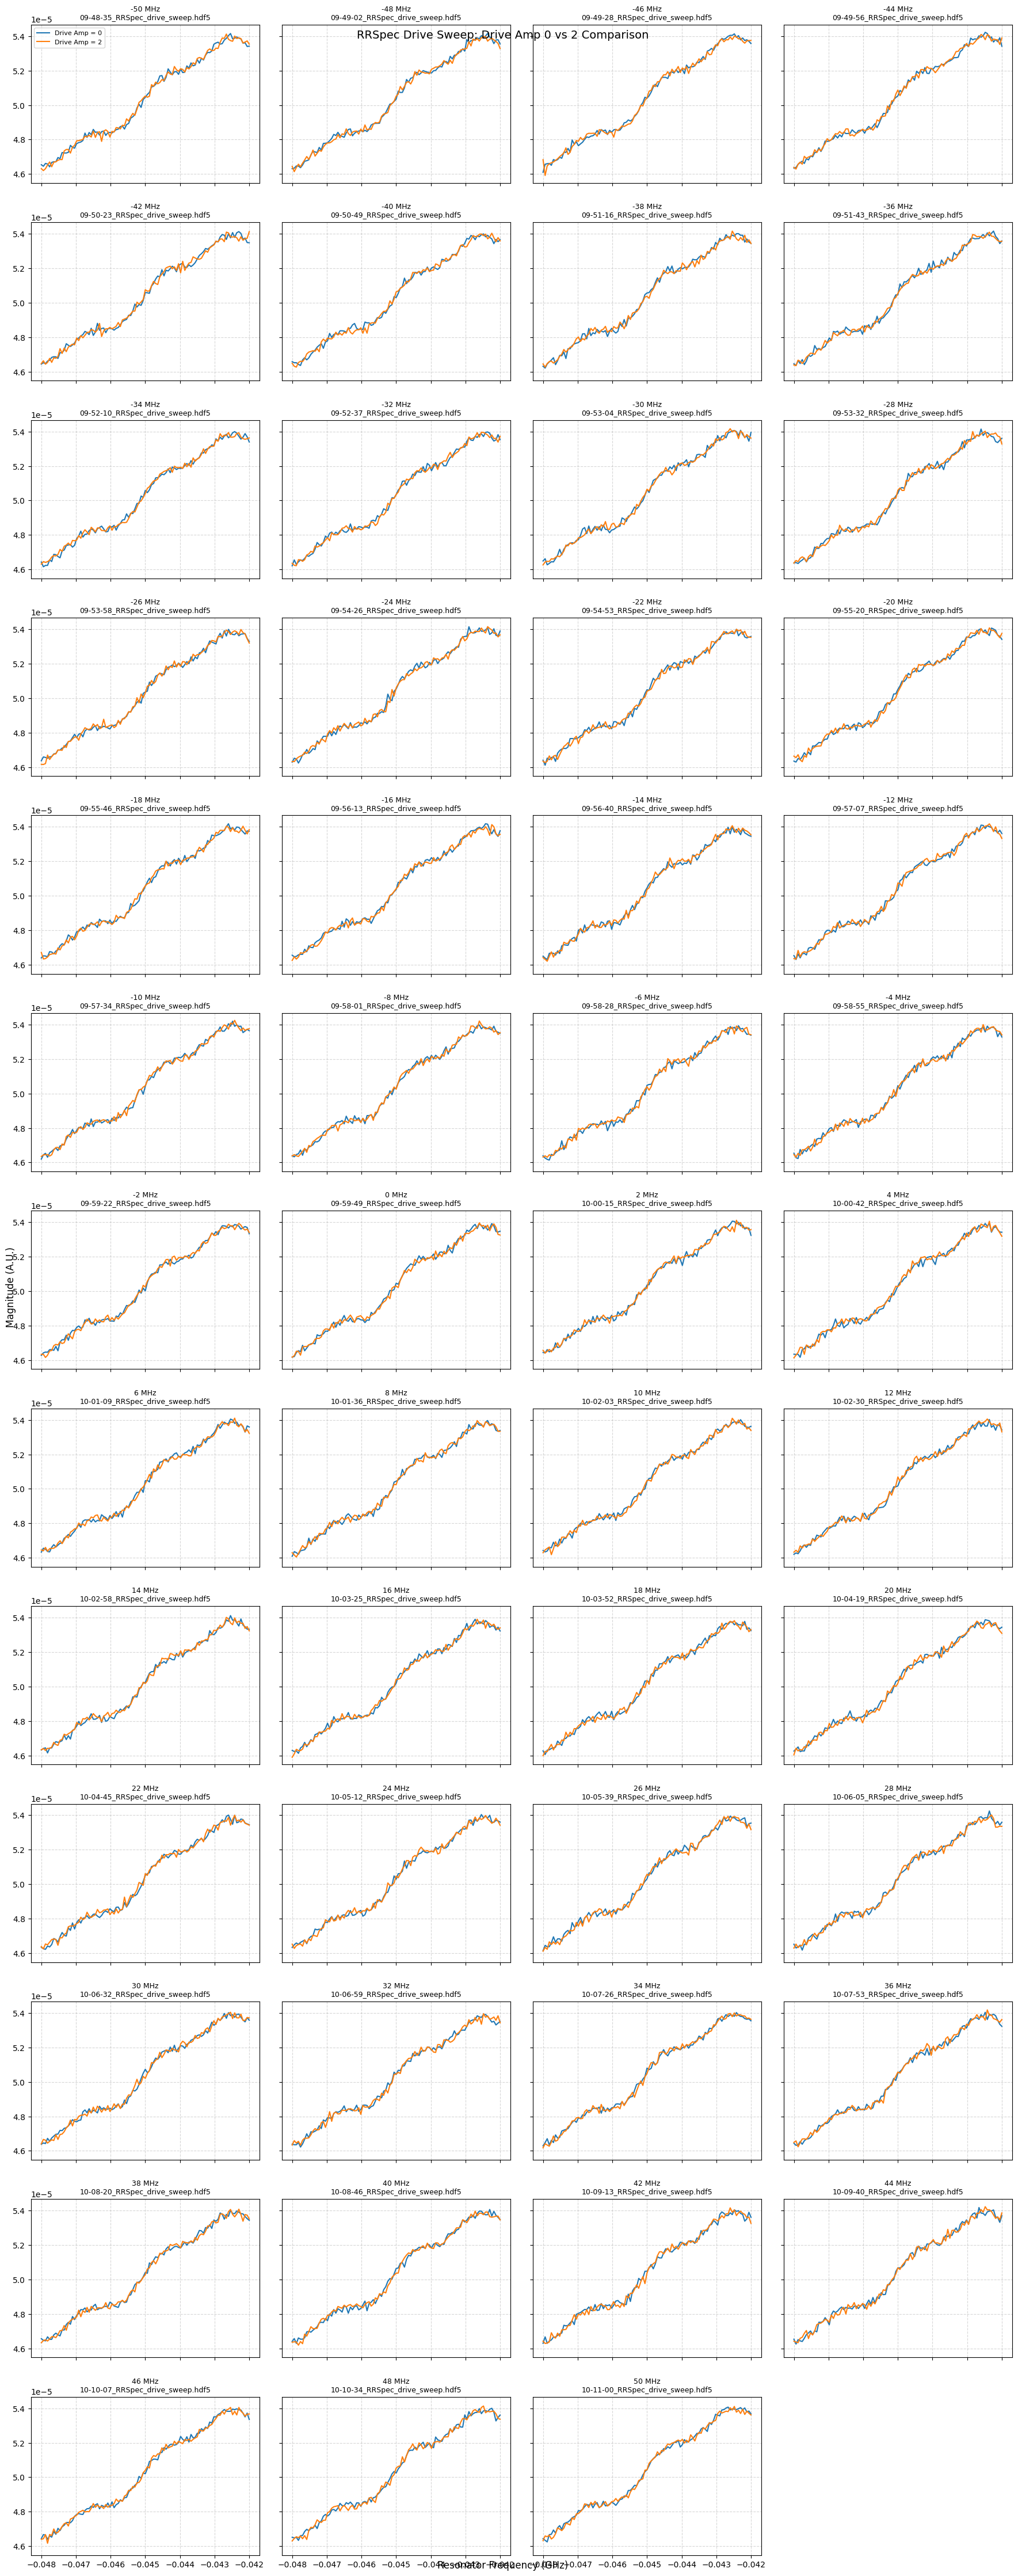

In [102]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
start = -50
step = 2
num = 51

search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-23",
        "start": "09-48-00",
        "stop": "10-11-00",
        "drive_IF": np.arange(start, start + num * step, step)
    },
]

# ==========================================================
# 2. Collect files and assign flux values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["drive_IF"]):
        raise ValueError(
            f"Expected {len(cfg['drive_IF'])} files, but found {len(files)}."
        )

    for drive_IF, file in zip(cfg["drive_IF"], files):
        paired_data.append((drive_IF, file))

# Sort by drive_IF for plotting
paired_data.sort(key=lambda x: x[0])

drive_IF_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in drive_IF order:\n")
for drive_IF, file in zip(drive_IF_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> drive_IF: {drive_IF} MHz")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0 and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp2_list = []
filename_list = []

for drive_IF, file_path in zip(drive_IF_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0 and drive_ampx = 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Save processed slices to NPZ
np.savez(
    "stark_shift_magnitude_traces.npz",
    drive_IF=drive_IF_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("\nSaved stark_shift_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot both line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    drive_IF_MHz = drive_IF_sweep_sorted[i] / 1e6 if drive_IF_sweep_sorted[i] >= 1e3 else drive_IF_sweep_sorted[i]
    label = f"{drive_IF_MHz:g} MHz\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("RRSpec Drive Sweep: Drive Amp 0 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-23
Found 26 files

Files in delay order:

14-19-08_RRSpec_drive_sweep.hdf5 -> Delay: 16 ns
14-19-29_RRSpec_drive_sweep.hdf5 -> Delay: 216 ns
14-19-50_RRSpec_drive_sweep.hdf5 -> Delay: 416 ns
14-20-11_RRSpec_drive_sweep.hdf5 -> Delay: 616 ns
14-20-32_RRSpec_drive_sweep.hdf5 -> Delay: 816 ns
14-20-54_RRSpec_drive_sweep.hdf5 -> Delay: 1016 ns
14-21-16_RRSpec_drive_sweep.hdf5 -> Delay: 1216 ns
14-21-38_RRSpec_drive_sweep.hdf5 -> Delay: 1416 ns
14-22-00_RRSpec_drive_sweep.hdf5 -> Delay: 1616 ns
14-22-22_RRSpec_drive_sweep.hdf5 -> Delay: 1816 ns
14-22-44_RRSpec_drive_sweep.hdf5 -> Delay: 2016 ns
14-23-07_RRSpec_drive_sweep.hdf5 -> Delay: 2216 ns
14-23-29_RRSpec_drive_sweep.hdf5 -> Delay: 2416 ns
14-23-51_RRSpec_drive_sweep.hdf5 -> Delay: 2616 ns
14-24-15_RRSpec_drive_sweep.hdf5 -> Delay: 2816 ns
14-24-37_RRSpec_drive_sweep.hdf5 -> Delay: 3016 ns
14-25-01_RRSpec_drive_sweep.hdf5 -> Delay: 3216 ns
14-25-25_RRSpec_drive_sweep.hdf5 ->

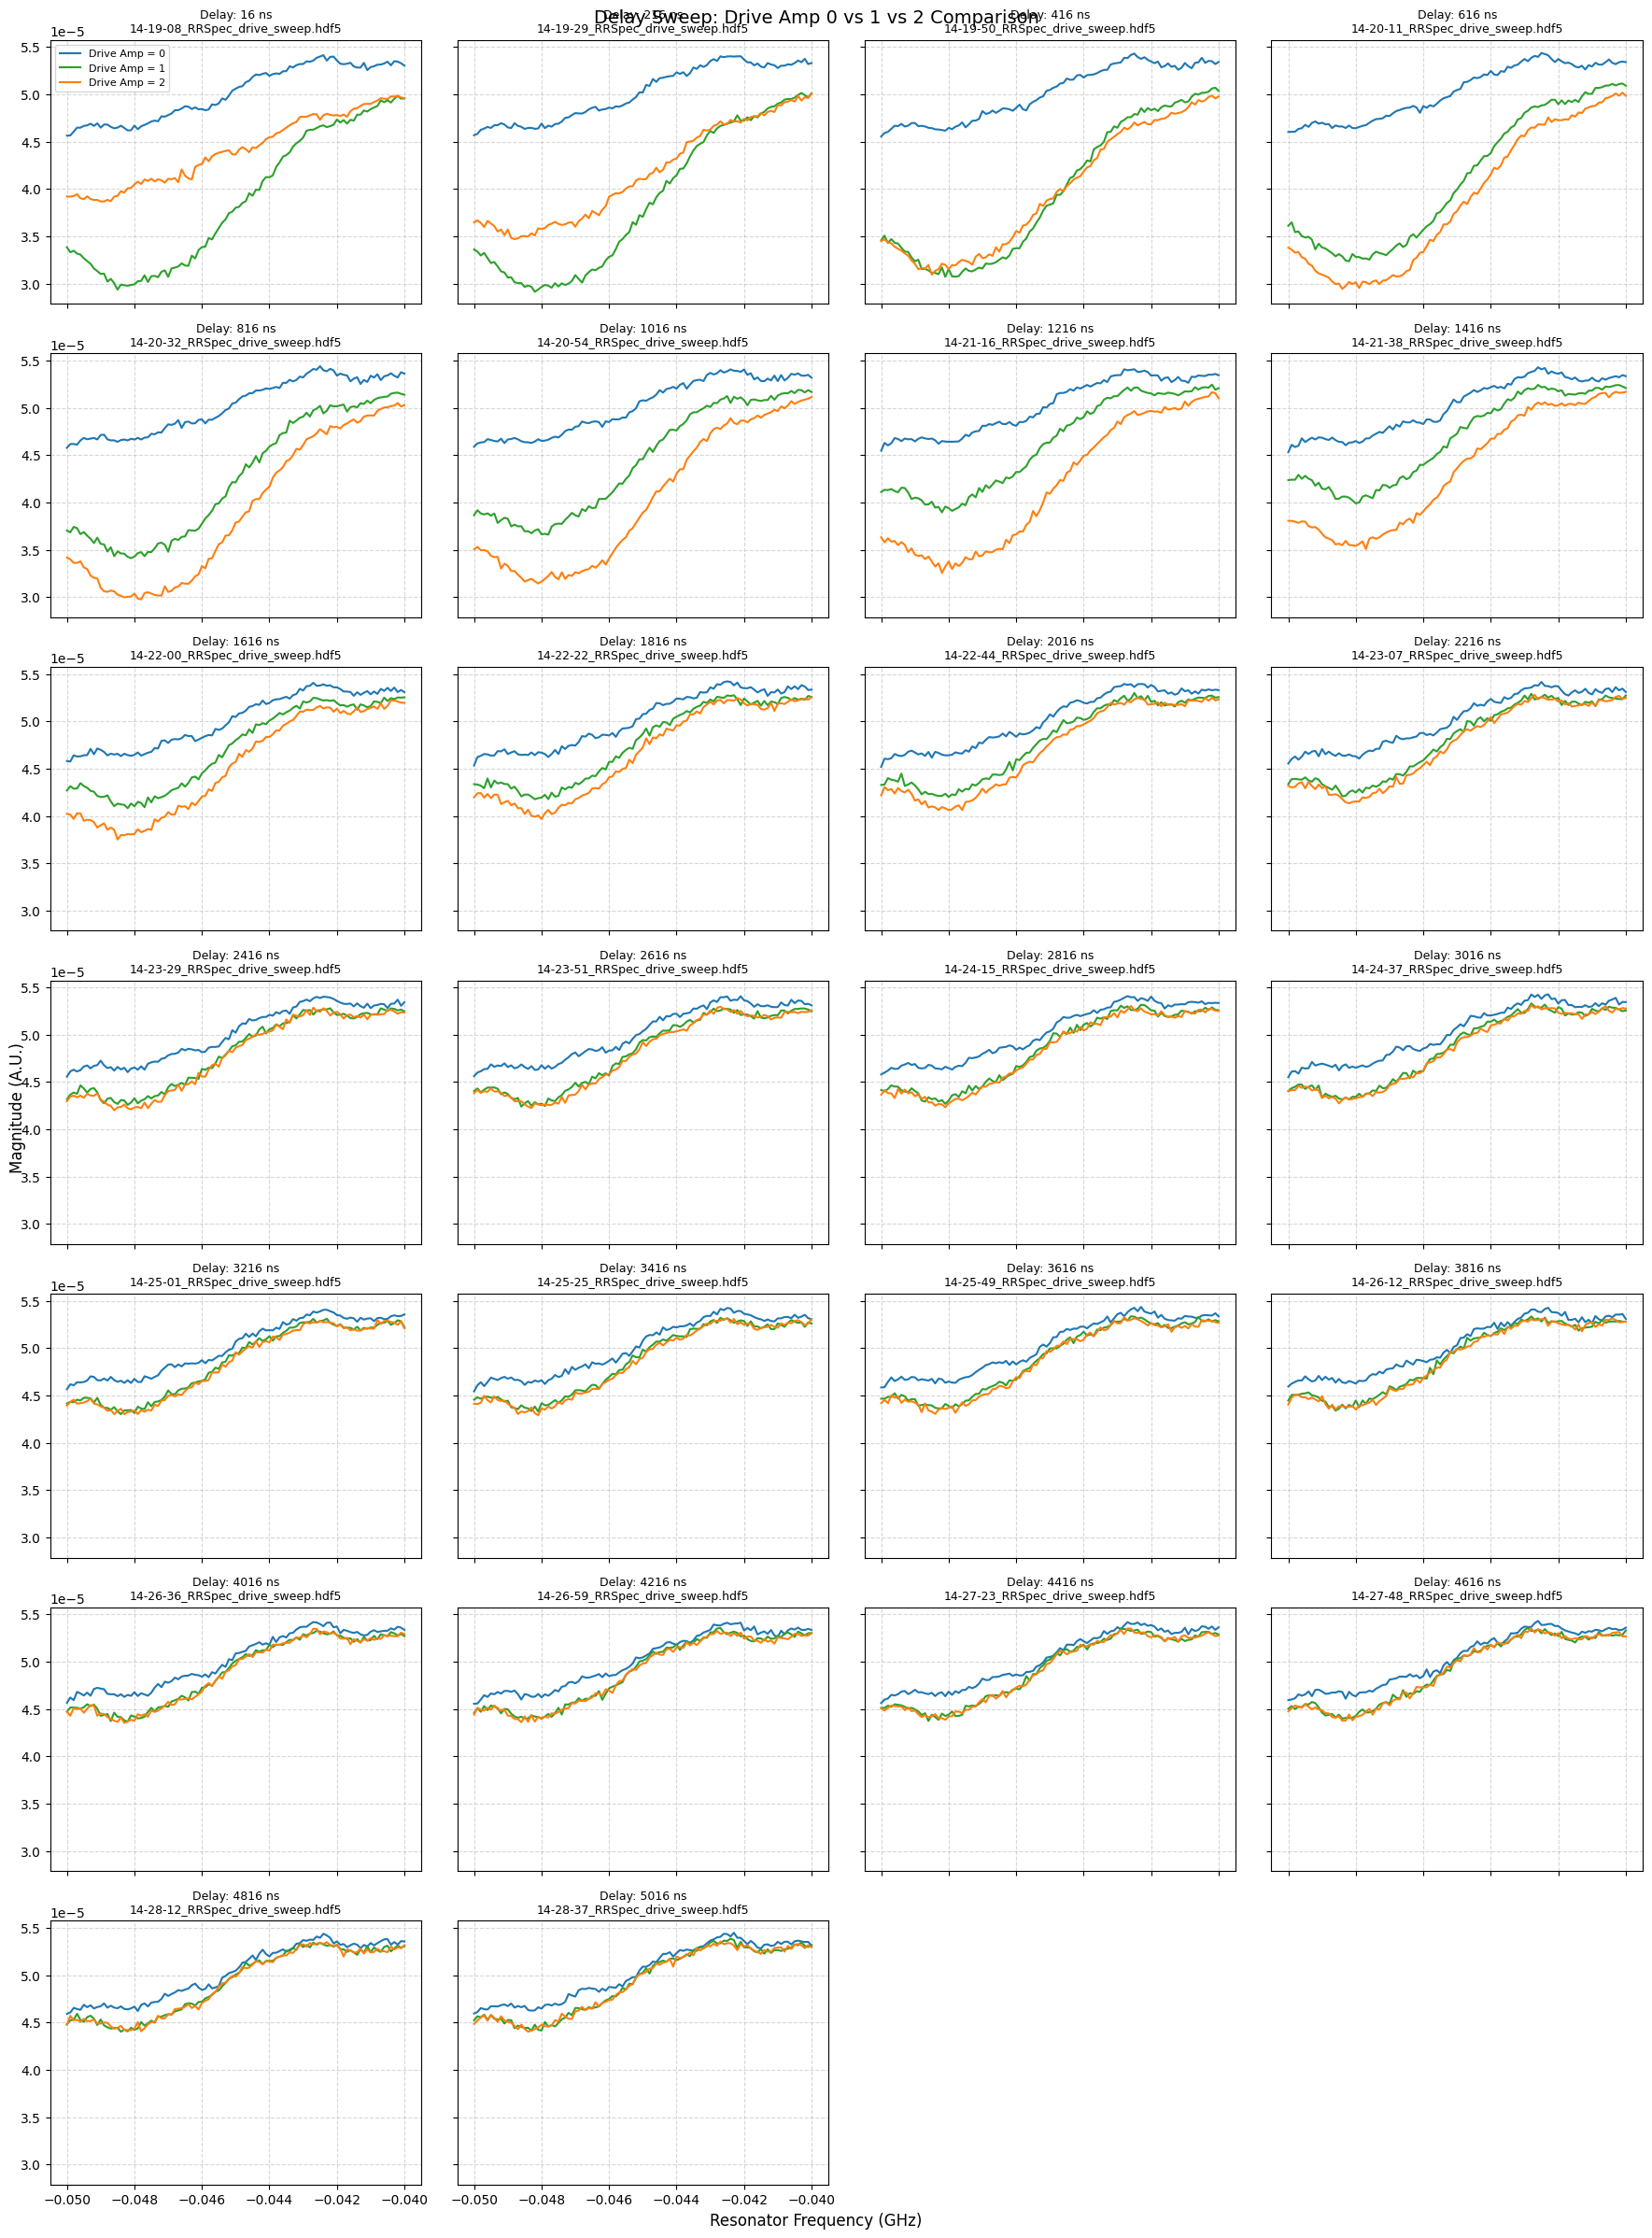

In [109]:
from datetime import datetime
import glob
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Search Configuration
# ==========================================================
start = 16    # Start delay in ns
step = 200    # Delay step in ns
num = 26       # Number of delay points

search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-23",
        "start": "14-19-00",
        "stop": "14-29-00",
        "delay": np.arange(start, start + num * step, step) # Delay in ns
    },
]

# ==========================================================
# 2. Collect files and assign delay values
# ==========================================================
paired_data = []

for cfg in search_configs:
    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):
        filename = os.path.basename(file_path)

        if "RRSpec_drive_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0], "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["delay"]):
        raise ValueError(
            f"Expected {len(cfg['delay'])} files, but found {len(files)}."
        )

    for delay, file in zip(cfg["delay"], files):
        paired_data.append((delay, file))

# Sort by delay for plotting
paired_data.sort(key=lambda x: x[0])

delay_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

print("\nFiles in delay order:\n")
for delay, file in zip(delay_sweep_sorted, collected_files_sorted):
    print(f"{os.path.basename(file)} -> Delay: {delay} ns")

# ==========================================================
# 3. Load Magnitude data & slices for Drive Amp = 0, 1, and 2
# ==========================================================
freq_list = []
mag_amp0_list = []
mag_amp1_list = []
mag_amp2_list = []
filename_list = []

for delay, file_path in zip(delay_sweep_sorted, collected_files_sorted):
    with h5py.File(file_path, "r") as data:
        # Load Magnitude averaged over iteration axis (axis 0)
        if "Magnitude" in data:
            mag = np.mean(np.array(data["Magnitude"]), axis=0)
        else:
            i_data = np.mean(np.array(data["I"]), axis=0)
            q_data = np.mean(np.array(data["Q"]), axis=0)
            mag = np.sqrt(i_data**2 + q_data**2)

        freq = np.array(data["resonator_frequency"])
        drive_amp = np.array(data["drive_ampx"])

    # Locate nearest indices for drive_ampx = 0, 1, and 2
    idx_amp0 = np.argmin(np.abs(drive_amp - 0.0))
    idx_amp1 = np.argmin(np.abs(drive_amp - 1.0))
    idx_amp2 = np.argmin(np.abs(drive_amp - 2.0))

    # Extract 1D slices depending on array orientation
    if mag.shape[0] == len(drive_amp):
        mag_amp0 = mag[idx_amp0, :]
        mag_amp1 = mag[idx_amp1, :]
        mag_amp2 = mag[idx_amp2, :]
    else:
        mag_amp0 = mag[:, idx_amp0]
        mag_amp1 = mag[:, idx_amp1]
        mag_amp2 = mag[:, idx_amp2]

    freq_list.append(freq)
    mag_amp0_list.append(mag_amp0)
    mag_amp1_list.append(mag_amp1)
    mag_amp2_list.append(mag_amp2)
    filename_list.append(os.path.basename(file_path))

# Print summary table of extracted values (Min values / dip positions)
print("\n" + "=" * 70)
print(f"{'Delay (ns)':<12} | {'Filename':<22} | {'Amp 0 (Min)':<10} | {'Amp 1 (Min)':<10} | {'Amp 2 (Min)':<10}")
print("=" * 70)

for d, fname, m0, m1, m2 in zip(delay_sweep_sorted, filename_list, mag_amp0_list, mag_amp1_list, mag_amp2_list):
    print(f"{d:<12.1f} | {fname:<22} | {np.min(m0):<10.4e} | {np.min(m1):<10.4e} | {np.min(m2):<10.4e}")

print("=" * 70 + "\n")

# Save processed slices to NPZ
np.savez(
    "stark_shift_delay_magnitude_traces.npz",
    delay=delay_sweep_sorted,
    filenames=filename_list,
    frequency=np.array(freq_list, dtype=object),
    mag_amp0=np.array(mag_amp0_list, dtype=object),
    mag_amp1=np.array(mag_amp1_list, dtype=object),
    mag_amp2=np.array(mag_amp2_list, dtype=object),
)
print("Saved stark_shift_delay_magnitude_traces.npz successfully.")

# ==========================================================
# 4. Plot Grid: 1D Line Traces overlaying Drive Amp 0, 1 & 2
# ==========================================================
num_plots = len(freq_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4.5 * cols, 3.5 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.flatten()

for i in range(num_plots):
    ax = axes_flat[i]
    freq_GHz = freq_list[i] / 1e9  # Convert Hz to GHz

    # Plot all three line slices on the same subplot
    ax.plot(freq_GHz, mag_amp0_list[i], label="Drive Amp = 0", color="tab:blue", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp1_list[i], label="Drive Amp = 1", color="tab:green", linewidth=1.5)
    ax.plot(freq_GHz, mag_amp2_list[i], label="Drive Amp = 2", color="tab:orange", linewidth=1.5)

    delay_ns = delay_sweep_sorted[i]
    label = f"Delay: {delay_ns:g} ns\n{filename_list[i]}"
    ax.set_title(label, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add legend to first subplot
axes_flat[0].legend(fontsize=8)

# Remove unused subplots
for j in range(num_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.supxlabel("Resonator Frequency (GHz)")
fig.supylabel("Magnitude (A.U.)")

plt.suptitle("Delay Sweep: Drive Amp 0 vs 1 vs 2 Comparison", fontsize=14)
plt.tight_layout()
plt.show()

Keys: ['snail_frequency', 'drive_ampx', 'I', 'Q', 'Magnitude']
Raw I shape: (300, 501, 18)
Raw qubit_frequency shape: (501,)
Raw drive_amp shape: (18,)
Reduced I shape (drive_amp, qubit_freq): (300, 501)
Sliced I shape: (300, 250)
Sliced qubit_freq shape: (250,)
Reduced I shape (drive_amp, qubit_freq): (300, 250)
drive_amp = 0.000 | peak = -117.062 MHz | gamma = 0.657 MHz
drive_amp = 0.100 | peak = -297.738 MHz | gamma = 0.451 MHz
drive_amp = 0.200 | peak = -312.073 MHz | gamma = 0.707 MHz
drive_amp = 0.400 | peak = -273.998 MHz | gamma = 1.794 MHz
drive_amp = 0.400 | peak = -393.846 MHz | gamma = 0.518 MHz
drive_amp = 0.500 | peak = -201.444 MHz | gamma = 0.031 MHz
drive_amp = 0.600 | peak = -253.365 MHz | gamma = 7.289 MHz
drive_amp = 0.700 | peak = -240.324 MHz | gamma = 22.638 MHz
drive_amp = 0.800 | peak = -290.026 MHz | gamma = 0.021 MHz
drive_amp = 0.900 | peak = -328.001 MHz | gamma = 0.073 MHz
drive_amp = 1.000 | peak = -327.397 MHz | gamma = 0.853 MHz
drive_amp = 1.100 | peak

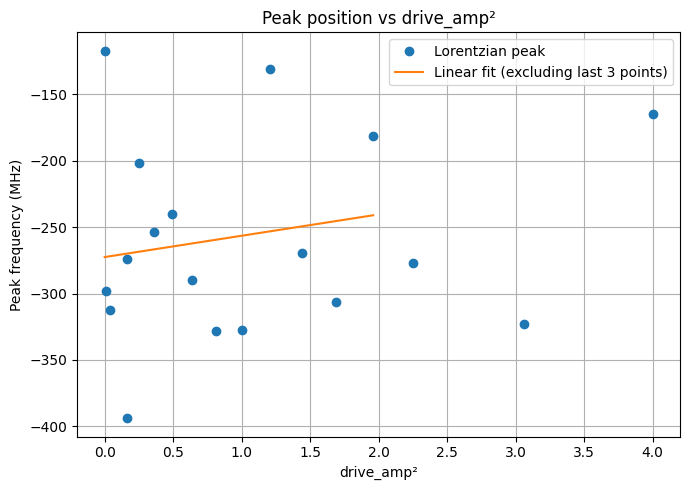

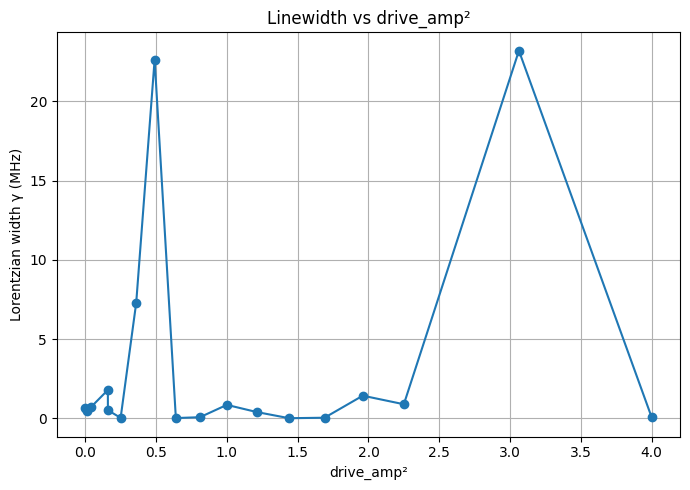

In [34]:
# ===========================
# Single-file Lorentzian Fit
# + Linear Fit vs drive_amp²
# ===========================

import numpy as np
import matplotlib.pyplot as plt
import h5py
from lmfit import Model, Parameters
from pathlib import Path

# ---------------------------
# File path
# ---------------------------
file_path = Path(
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-21\15-49-12_snail_stark_shift_sweep.hdf5"
)

# ---------------------------
# Recursive dataset finder
# ---------------------------
def find_dataset(name, group):
    for key in group.keys():
        item = group[key]
        if isinstance(item, h5py.Dataset) and key == name:
            return item[()]
        elif isinstance(item, h5py.Group):
            result = find_dataset(name, item)
            if result is not None:
                return result
    return None

# ---------------------------
# Load data
# ---------------------------
with h5py.File(file_path, "r") as f:
    print("Keys:", list(f.keys()))

    I = find_dataset("I", f)
    Q = find_dataset("Q", f)

    # Key names updated to match the printed keys from your file:
    qubit_freq = find_dataset("snail_frequency", f)
    drive_amp = find_dataset("drive_ampx", f)

# Safeguard check
if I is None or qubit_freq is None or drive_amp is None:
    raise ValueError("One or more datasets could not be found in the HDF5 file.")

# ---------------------------
# Convert arrays
# ---------------------------
# ---------------------------
# Convert arrays
# ---------------------------
I = np.array(I)
qubit_freq = np.array(qubit_freq)
drive_amp = np.array(drive_amp)

print("Raw I shape:", I.shape)
print("Raw qubit_frequency shape:", qubit_freq.shape)
print("Raw drive_amp shape:", drive_amp.shape)

# ---------------------------
# Handle averaging & axis ordering
# ---------------------------
# Average over extra dimensions (e.g. repetitions) until ndim == 2
while I.ndim > 2:
    I = np.mean(I, axis=-1)

# Ensure axis 0 corresponds to drive_amp (length equal to drive_amp.size)
if I.shape[0] != drive_amp.size and I.shape[1] == drive_amp.size:
    I = I.T

print("Reduced I shape (drive_amp, qubit_freq):", I.shape)

# ---------------------------
# Slice frequency range (Fix applied here!)
# ---------------------------
# Slice both the frequency array and the second axis of I to keep dimensions aligned:
qubit_freq = qubit_freq[0:250]
I = I[:, 0:250]

print("Sliced I shape:", I.shape)
print("Sliced qubit_freq shape:", qubit_freq.shape)
# ---------------------------
# Handle averaging & axis ordering
# ---------------------------
# Average over extra dimensions (like repetitions/averages) until ndim == 2
while I.ndim > 2:
    I = np.mean(I, axis=-1)  # Averages over the last axis (e.g. 18 repeated measurements)

# Ensure axis 0 corresponds to drive_amp (length equal to drive_amp.size)
if I.shape[0] != drive_amp.size and I.shape[1] == drive_amp.size:
    I = I.T

print("Reduced I shape (drive_amp, qubit_freq):", I.shape)

# ---------------------------
# Lorentzian fit
# ---------------------------
def lorentzian_fit(y, x):
    def lorentzian(x, amp=1, x0=0, gamma=1, ofs=0):
        return amp * gamma**2 / ((x - x0)**2 + gamma**2) + ofs

    model = Model(lorentzian)
    params = Parameters()

    peak_idx = np.argmax(y)

    params.add("amp", value=np.max(y) - np.min(y))
    params.add("x0", value=x[peak_idx])
    params.add("gamma", value=(x[-1] - x[0]) / 20, min=1e-6)
    params.add("ofs", value=np.min(y))

    result = model.fit(y, params, x=x)
    return result

# ---------------------------
# Linear fit
# ---------------------------
def linear_fit(x, y):
    coeffs = np.polyfit(x, y, 1)
    slope = coeffs[0]
    intercept = coeffs[1]
    fit_y = slope * x + intercept
    return slope, intercept, fit_y

# ---------------------------
# Analyze all drive amplitudes
# ---------------------------
peak_positions = []
peak_widths = []

for i, amp in enumerate(drive_amp):
    y = I[i]

    try:
        fit = lorentzian_fit(y, qubit_freq)
        peak_freq = fit.params["x0"].value
        gamma = fit.params["gamma"].value

        peak_positions.append(peak_freq)
        peak_widths.append(gamma)

        print(
            f"drive_amp = {amp:.3f} | "
            f"peak = {peak_freq/1e6:.3f} MHz | "
            f"gamma = {gamma/1e6:.3f} MHz"
        )

    except Exception as e:
        print(f"Fit failed at drive_amp={amp}: {e}")
        peak_positions.append(np.nan)
        peak_widths.append(np.nan)

# ---------------------------
# Convert arrays
# ---------------------------
peak_positions = np.array(peak_positions)
peak_widths = np.array(peak_widths)

drive_amp_sq = drive_amp**2

# ---------------------------
# Remove NaNs
# ---------------------------
mask = np.isfinite(drive_amp_sq) & np.isfinite(peak_positions)

x = drive_amp_sq[mask]
y = peak_positions[mask]

# ---------------------------
# Linear fit (excluding last 3 points)
# ---------------------------
if len(x) > 3:
    x_fit = x[:-3]
    y_fit = y[:-3]
else:
    x_fit = x
    y_fit = y

slope, intercept, fit_y = linear_fit(x_fit, y_fit)

print("\n===== Linear Fit =====")
print(f"Slope     = {slope:.6e} Hz / amp²")
print(f"Intercept = {intercept:.6e} Hz")

# ---------------------------
# Sort for plotting
# ---------------------------
sort_all = np.argsort(x)
x_sorted = x[sort_all]
y_sorted = y[sort_all]

sort_fit = np.argsort(x_fit)
x_fit_sorted = x_fit[sort_fit]
fit_sorted = fit_y[sort_fit]

# ---------------------------
# Plot peak positions
# ---------------------------
plt.figure(figsize=(7,5))

plt.plot(
    x_sorted,
    y_sorted / 1e6,
    'o',
    label='Lorentzian peak'
)

plt.plot(
    x_fit_sorted,
    fit_sorted / 1e6,
    '-',
    label='Linear fit (excluding last 3 points)'
)

plt.xlabel("drive_amp²")
plt.ylabel("Peak frequency (MHz)")
plt.title("Peak position vs drive_amp²")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------
# Plot linewidth
# ---------------------------
plt.figure(figsize=(7,5))

plt.plot(
    drive_amp_sq,
    peak_widths / 1e6,
    'o-'
)

plt.xlabel("drive_amp²")
plt.ylabel("Lorentzian width γ (MHz)")
plt.title("Linewidth vs drive_amp²")

plt.grid(True)
plt.tight_layout()
plt.show()